In [3]:
# ============================================
# Standard library imports
# ============================================
import re
import sys
import json
import pickle
import logging
import random
import subprocess
import warnings
import collections
import itertools
from pathlib import Path

import gzip

import numpy as np
import pandas as pd

from sklearn import model_selection, metrics

from IPython.display import display

warnings.filterwarnings("ignore")

# ============================================
# Numeric / statistics
# ============================================
import numpy as np
import pandas as pd

import scipy
from scipy import stats
from scipy.stats import rankdata

# ============================================
# Plotting / visualization
# ============================================
import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec

import seaborn as sns

from upsetplot import UpSet, from_memberships

# ============================================
# scikit-learn
# ============================================
from sklearn import model_selection, metrics
from sklearn.neighbors import LocalOutlierFactor
from sklearn.inspection import permutation_importance
from sklearn import __version__ as sklearn_version

# ============================================
# Optimization
# ============================================
import optuna

# ============================================
# LightGBM
# ============================================
try:
    import lightgbm as lgb
    from lightgbm import LGBMRegressor
except Exception as e:
    raise RuntimeError(
        "LightGBM is not installed. Please install it with `pip install lightgbm`."
    ) from e

# ============================================
# RNA structure
# Later this can be removed if all structure features are precomputed by script.
# ============================================
import RNA

# ============================================
# Model explanation
# ============================================
import shap

# ============================================
# User utilities
# ============================================
import sylib

# ============================================
# Version info
# ============================================
print(f"python    = {sys.version_info[0]}.{sys.version_info[1]}.{sys.version_info[2]}")
print(f"pandas    = {pd.__version__}")
print(f"numpy     = {np.__version__}")
print(f"scipy     = {scipy.__version__}")
print(f"sklearn   = {sklearn_version}")
print(f"optuna    = {optuna.__version__}")
print(f"lightgbm  = {lgb.__version__}")
print(f"ViennaRNA = {RNA.__version__}")
print(f"sylib     = {sylib.__version__}")

# ============================================
# Logging
# ============================================
logging.root.handlers = []

stream_handler = logging.StreamHandler(sys.stderr)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)8s: %(message)s",
    handlers=[stream_handler],
)

logger = logging.getLogger(__name__)

logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("lightgbm").setLevel(logging.WARNING)

python    = 3.11.15
pandas    = 2.3.3
numpy     = 2.4.6
scipy     = 1.17.1
sklearn   = 1.9.0
optuna    = 4.9.0
lightgbm  = 4.6.0
ViennaRNA = 2.7.2
sylib     = 0.3.0.dev0+ae18bb2


In [4]:
# ============================================
# Global plotting configuration
# ============================================

_PLOT_CFG = {
    "fig_w": 6.0,
    "fig_h": 6.0,
    "dpi": 300,
}


SPECIES_INFO = {
    "AT21": {
        "label": "AT",
        "short": "AT21",
        "color": "#664D0AFF",
        "marker": "o",
    },
    "NB21": {
        "label": "NB",
        "short": "NB21",
        "color": "#7e3131",
        "marker": "^",
    },
    "OS21": {
        "label": "OS",
        "short": "OS21",
        "color": "#13563f",
        "marker": "s",
    },
}

def set_plot_style(
    *,
    base_fontsize=10,
    title_fontsize=12,
    label_fontsize=10,
    tick_fontsize=9,
    legend_fontsize=10,
    dpi=300,
    axes_linewidth=1.2,
    spines_top=True,
    spines_right=True,
    tick_size_major=6,
    tick_dir="out",
    grid=False,
    fig_w=6.0,
    fig_h=6.0,
):
    sns.set_style("ticks")

    mpl.rcParams.update({
        "font.family": "DejaVu Sans",
        "font.size": base_fontsize,

        "axes.titlesize": title_fontsize,
        "axes.labelsize": label_fontsize,

        "xtick.labelsize": tick_fontsize,
        "ytick.labelsize": tick_fontsize,

        "legend.fontsize": legend_fontsize,

        "figure.dpi": dpi,
        "savefig.dpi": dpi,

        "axes.linewidth": axes_linewidth,
        "axes.spines.top": spines_top,
        "axes.spines.right": spines_right,
        "axes.grid": grid,
        "axes.axisbelow": True,

        "xtick.major.size": tick_size_major,
        "ytick.major.size": tick_size_major,
        "xtick.direction": tick_dir,
        "ytick.direction": tick_dir,

        "legend.frameon": False,

        "savefig.bbox": "tight",
        "savefig.transparent": False,
        "figure.autolayout": False,
    })

    _PLOT_CFG.update({
        "fig_w": fig_w,
        "fig_h": fig_h,
        "dpi": dpi,
    })


def make_fig(w=None, h=None, dpi=None):
    W = float(w) if w is not None else _PLOT_CFG["fig_w"]
    H = float(h) if h is not None else _PLOT_CFG["fig_h"]
    D = dpi if dpi is not None else _PLOT_CFG["dpi"]

    fig, ax = plt.subplots(
        figsize=(W, H),
        dpi=D,
    )

    return fig, ax


def _compact_formatter():
    def _fmt(x, _pos=None):
        axx = abs(x)

        if axx >= 1e9:
            s = f"{x / 1e9:.1f}B"
        elif axx >= 1e6:
            s = f"{x / 1e6:.1f}M"
        elif axx >= 1e3:
            s = f"{x / 1e3:.1f}k"
        else:
            s = f"{x:.2g}"

        return (
            s.replace(".0B", "B")
             .replace(".0M", "M")
             .replace(".0k", "k")
        )

    return FuncFormatter(_fmt)


def format_axis(
    ax,
    *,
    xlabel=None,
    ylabel=None,
    compact_ticks=(),
):
    if xlabel is not None:
        ax.set_xlabel(xlabel)

    if ylabel is not None:
        ax.set_ylabel(ylabel)

    fmt = _compact_formatter()

    if "x" in compact_ticks:
        ax.xaxis.set_major_formatter(fmt)

    if "y" in compact_ticks:
        ax.yaxis.set_major_formatter(fmt)

    return ax


# ============================================
# Joint scatter with KDE marginals
# ============================================

def safe_pearsonr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.nan, np.nan

    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan

    return stats.pearsonr(x, y)


def safe_spearmanr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.nan, np.nan

    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan

    return stats.spearmanr(x, y)

def _kde_1d(values, lo, hi, num=256):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    grid = np.linspace(lo, hi, num)

    if len(values) < 2:
        return grid, np.zeros_like(grid)

    try:
        kde = stats.gaussian_kde(values)
        dens = kde(grid)
        dens /= dens.max() if dens.max() > 0 else 1
        return grid, dens

    except Exception:
        return grid, np.zeros_like(grid)


def joint_scatter(
    x,
    y,
    *,
    color=None,
    point_size=18,
    alpha=0.65,
    show_identity=True,
    show_regression=True,
    annotate=True,
    annotate_spearman=True,
    xlabel=None,
    ylabel=None,
    title=None,
    figsize=None,
    w=None,
    h=None,
    dpi=None,
    annotate_fontsize=14,
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    n = len(x)

    if figsize is not None:
        FW, FH = figsize
    else:
        FW = float(w) if w is not None else _PLOT_CFG["fig_w"]
        FH = float(h) if h is not None else _PLOT_CFG["fig_h"]

    fig = plt.figure(
        figsize=(FW, FH),
        dpi=(dpi or _PLOT_CFG["dpi"]),
    )

    gs = GridSpec(
        2,
        2,
        width_ratios=(4, 1),
        height_ratios=(1, 4),
        hspace=0.05,
        wspace=0.05,
    )

    ax_top = fig.add_subplot(gs[0, 0])
    ax_joint = fig.add_subplot(gs[1, 0], sharex=ax_top)
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_joint)

    ax_joint.scatter(
        x,
        y,
        s=point_size,
        alpha=alpha,
        edgecolor="none",
        color=color,
    )

    lo = float(np.nanmin([x.min(), y.min()]))
    hi = float(np.nanmax([x.max(), y.max()]))

    pad = 0.05 * (hi - lo if hi > lo else 1.0)

    lo -= pad
    hi += pad

    ax_joint.set_xlim(lo, hi)
    ax_joint.set_ylim(lo, hi)

    if show_identity:
        ax_joint.plot(
            [lo, hi],
            [lo, hi],
            ls="--",
            lw=1.2,
            color="0.65",
            zorder=1,
        )

    if show_regression and n >= 2 and np.std(x) > 0 and np.std(y) > 0:
        slope, intercept = np.polyfit(x, y, 1)

        ax_joint.plot(
            [lo, hi],
            slope * np.array([lo, hi]) + intercept,
            color="black",
            lw=1.5,
            zorder=2,
        )

    format_axis(
        ax_joint,
        xlabel=xlabel,
        ylabel=ylabel,
        compact_ticks=(),
    )

    if title:
        ax_joint.set_title(title)

    if annotate and n >= 2 and np.std(x) > 0 and np.std(y) > 0:
        rp, _ = safe_pearsonr(x, y)
        rs, _ = safe_spearmanr(x, y)

        txt = rf"$r_p = {rp:.2f}$"

        if annotate_spearman:
            txt += "\n" + rf"$r_s = {rs:.2f}$"

        txt += f"\n$n = {n}$"

        ax_joint.text(
            0.04,
            0.96,
            txt,
            transform=ax_joint.transAxes,
            ha="left",
            va="top",
            fontsize=annotate_fontsize,
        )

    gx, dx = _kde_1d(x, lo, hi)
    gy, dy = _kde_1d(y, lo, hi)

    ax_top.plot(gx, dx, lw=2, color=color)
    ax_top.axis("off")

    ax_right.plot(dy, gy, lw=2, color=color)
    ax_right.axis("off")

    plt.tight_layout()

    return fig, (ax_joint, ax_top, ax_right)


set_plot_style()

# ============================================
# Plot helper functions
# ============================================

def species_palette():
    return [
        SPECIES_INFO["AT21"]["color"],
        SPECIES_INFO["NB21"]["color"],
        SPECIES_INFO["OS21"]["color"],
    ]


def outside_legend(
    ax,
    *,
    title="Species",
    n_items=3,
    x=1.02,
    y=1.00,
):
    handles, labels = ax.get_legend_handles_labels()

    ax.legend(
        handles[:n_items],
        labels[:n_items],
        title=title,
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(x, y),
        borderaxespad=0,
    )

    return ax

In [5]:

RESULT_DIR = Path("../results")
LGBM_DIR = RESULT_DIR / "lgbm"

SPECIES = ["AT21", "NB21", "OS21"]

species_label = {
    "AT21": "AT",
    "NB21": "NB",
    "OS21": "OS",
}

threshold_feature_file = LGBM_DIR / "lgbm.retention_feature_sets.tsv.gz"

threshold_feature_df = pd.read_csv(
    threshold_feature_file,
    sep="\t",
)

print("Threshold feature sets")
print(threshold_feature_df.shape)

display(
    threshold_feature_df
    .groupby(["Species", "Cutoff"])
    .size()
    .rename("N_features")
    .reset_index()
)

Threshold feature sets
(10842, 3)


,Species,Cutoff,N_features
0,AT,0.00,449
1,AT,0.05,407
2,AT,0.10,373
3,AT,0.15,331
4,AT,0.20,313
5,AT,0.25,283
6,AT,0.30,243
7,AT,0.35,226
8,AT,0.40,189
9,AT,0.45,160


In [6]:
# ============================================
# Load saved LightGBM data bundles
# Inspect available objects
# ============================================

lgbm_bundles = {}

for species_key in SPECIES:
    bundle_file = LGBM_DIR / f"{species_key}.lgbm.data_bundle.pkl.gz"

    with gzip.open(bundle_file, "rb") as f:
        bundle = pickle.load(f)

    lgbm_bundles[species_key] = bundle

    print("=" * 60)
    print(species_key)
    print(f"File : {bundle_file.name}")
    print("Keys :", sorted(bundle.keys()))

    for key, value in bundle.items():
        if hasattr(value, "shape"):
            print(f"{key:25s} {value.shape}")
        elif isinstance(value, (list, tuple)):
            print(f"{key:25s} len={len(value)}")
        else:
            print(f"{key:25s} {type(value).__name__}")

AT21
File : AT21.lgbm.data_bundle.pkl.gz
Keys : ['feature_names', 'model', 'outlier_removal_method', 'score_col_name', 'species', 'test_bool_array', 'test_data_ratio', 'test_idx_array', 'test_metadata', 'train_bool_array', 'train_idx_array', 'train_metadata', 'x_test_model', 'x_test_raw', 'x_train_model', 'x_train_raw', 'x_xform_param_dict', 'xform_method', 'y_test_model', 'y_test_raw', 'y_train_model', 'y_train_raw', 'y_xform_kwargs']
species                   str
model                     str
score_col_name            str
feature_names             len=464
x_train_raw               (5698, 464)
x_test_raw                (1428, 464)
x_train_model             (5698, 464)
x_test_model              (1428, 464)
y_train_raw               (5698,)
y_test_raw                (1428,)
y_train_model             (5698,)
y_test_model              (1428,)
train_metadata            (5698, 7)
test_metadata             (1428, 7)
x_xform_param_dict        dict
y_xform_kwargs            dict
train_idx_arra

In [7]:
# ============================================
# Load full-model baselines and parameters
# ============================================

baseline_rows = []
best_params = {}

for species_key in SPECIES:
    metrics_file = LGBM_DIR / f"{species_key}.lgbm.metrics.tsv"
    params_file = LGBM_DIR / f"{species_key}.lgbm.best_params.tsv"

    metrics_df = pd.read_csv(metrics_file, sep="\t")
    params_df = pd.read_csv(params_file, sep="\t")

    test_row = metrics_df.loc[metrics_df["dataset"].str.lower() == "test"].iloc[0]

    if {"parameter", "value"}.issubset(params_df.columns):
        params = dict(zip(params_df["parameter"], params_df["value"]))
    elif {"Parameter", "Value"}.issubset(params_df.columns):
        params = dict(zip(params_df["Parameter"], params_df["Value"]))
    else:
        params = params_df.iloc[0].dropna().to_dict()

    best_params[species_key] = params

    baseline_rows.append({
        "Species_key": species_key,
        "Species": species_label[species_key],
        "Full_R2": test_row["R2"],
        "Full_Pearson_r": test_row["Pearson_r"],
        "Full_RMSE": test_row["RMSE"],
        "Full_MAE": test_row["MAE"],
    })

baseline_df = pd.DataFrame(baseline_rows)

print("Full-model test baselines")
display(baseline_df)

print("\nSaved LightGBM parameters")
for species_key, params in best_params.items():
    print(species_key, params)

Full-model test baselines


,Species_key,Species,Full_R2,Full_Pearson_r,Full_RMSE,Full_MAE
0,AT21,AT,0.291471,0.541506,0.846832,0.646462
1,NB21,NB,0.294002,0.543576,0.855906,0.649270
2,OS21,OS,0.388360,0.623862,0.765434,0.587098



Saved LightGBM parameters
AT21 {'species': 'AT21', 'model': 'LightGBM', 'best_cv_R2': 0.2504868724505485, 'n_trials': 20, 'k_cv': 10, 'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 13, 'min_child_samples': 28, 'feature_fraction': 0.2, 'num_leaves': 39}
NB21 {'species': 'NB21', 'model': 'LightGBM', 'best_cv_R2': 0.3092222238921906, 'n_trials': 20, 'k_cv': 10, 'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_samples': 10, 'feature_fraction': 0.3, 'num_leaves': 31}
OS21 {'species': 'OS21', 'model': 'LightGBM', 'best_cv_R2': 0.3613909751208884, 'n_trials': 20, 'k_cv': 10, 'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_samples': 2, 'feature_fraction': 0.7, 'num_leaves': 44}


In [8]:
# ============================================
# Validate threshold-selected model features
# ============================================

validation_rows = []

for species_key in SPECIES:
    species = species_label[species_key]
    bundle = lgbm_bundles[species_key]

    model_features = set(bundle["x_train_model"].columns)
    selected_features = set(threshold_feature_df.loc[threshold_feature_df["Species"] == species, "Feature"])
    missing = selected_features - model_features

    validation_rows.append({
        "Species": species,
        "Model_features": len(model_features),
        "Threshold_features": len(selected_features),
        "Missing_features": len(missing),
    })

    assert not missing, f"{species_key}: missing features {sorted(missing)}"

feature_validation_df = pd.DataFrame(validation_rows)

print("Threshold-feature validation")
display(feature_validation_df)

Threshold-feature validation


,Species,Model_features,Threshold_features,Missing_features
0,AT,464,449,0
1,NB,464,449,0
2,OS,463,449,0


In [9]:
# ============================================
# Reduced-model CV performance
# ============================================

cv_rows = []

for species_key in SPECIES:
    species = species_label[species_key]
    bundle = lgbm_bundles[species_key]

    x_train = bundle["x_train_model"]
    y_train = bundle["y_train_model"]

    saved = best_params[species_key]
    tuned_params = {
        "max_depth": int(saved["max_depth"]),
        "min_child_samples": int(saved["min_child_samples"]),
        "feature_fraction": float(saved["feature_fraction"]),
        "num_leaves": int(saved["num_leaves"]),
    }

    k_cv = int(saved["k_cv"])
    cv = model_selection.KFold(n_splits=k_cv, shuffle=True, random_state=0)

    full_model = LGBMRegressor(
        objective="regression", n_estimators=int(saved["n_estimators"]),
        learning_rate=float(saved["learning_rate"]), random_state=0,
        n_jobs=1, verbosity=-1, **tuned_params,
    )

    full_scores = model_selection.cross_val_score(
        full_model, x_train, y_train, cv=cv, scoring="r2", n_jobs=10,
    )

    for cutoff in sorted(threshold_feature_df["Cutoff"].unique()):
        features = threshold_feature_df.loc[
            (threshold_feature_df["Species"] == species) &
            np.isclose(threshold_feature_df["Cutoff"], cutoff),
            "Feature",
        ].tolist()

        model = LGBMRegressor(
            objective="regression", n_estimators=int(saved["n_estimators"]),
            learning_rate=float(saved["learning_rate"]), random_state=0,
            n_jobs=1, verbosity=-1, **tuned_params,
        )

        scores = model_selection.cross_val_score(
            model, x_train[features], y_train,
            cv=cv, scoring="r2", n_jobs=10,
        )

        cv_rows.append({
            "Species": species,
            "Cutoff": cutoff,
            "N_features": len(features),
            "Full_CV_R2": full_scores.mean(),
            "Full_CV_R2_SD": full_scores.std(ddof=1),
            "Reduced_CV_R2": scores.mean(),
            "CV_R2_SD": scores.std(ddof=1),
        })

retention_cv_df = (
    pd.DataFrame(cv_rows)
    .sort_values(["Species", "Cutoff"])
    .reset_index(drop=True)
)

display(retention_cv_df)

,Species,Cutoff,N_features,Full_CV_R2,Full_CV_R2_SD,Reduced_CV_R2,CV_R2_SD
0,AT,0.00,449,0.250487,0.037655,0.246176,0.036747
1,AT,0.05,407,0.250487,0.037655,0.249711,0.037194
2,AT,0.10,373,0.250487,0.037655,0.253173,0.038253
3,AT,0.15,331,0.250487,0.037655,0.253356,0.033886
4,AT,0.20,313,0.250487,0.037655,0.248637,0.035945
5,AT,0.25,283,0.250487,0.037655,0.247786,0.033800
6,AT,0.30,243,0.250487,0.037655,0.253541,0.032040
7,AT,0.35,226,0.250487,0.037655,0.254394,0.032797
8,AT,0.40,189,0.250487,0.037655,0.253222,0.037942
9,AT,0.45,160,0.250487,0.037655,0.255678,0.037721


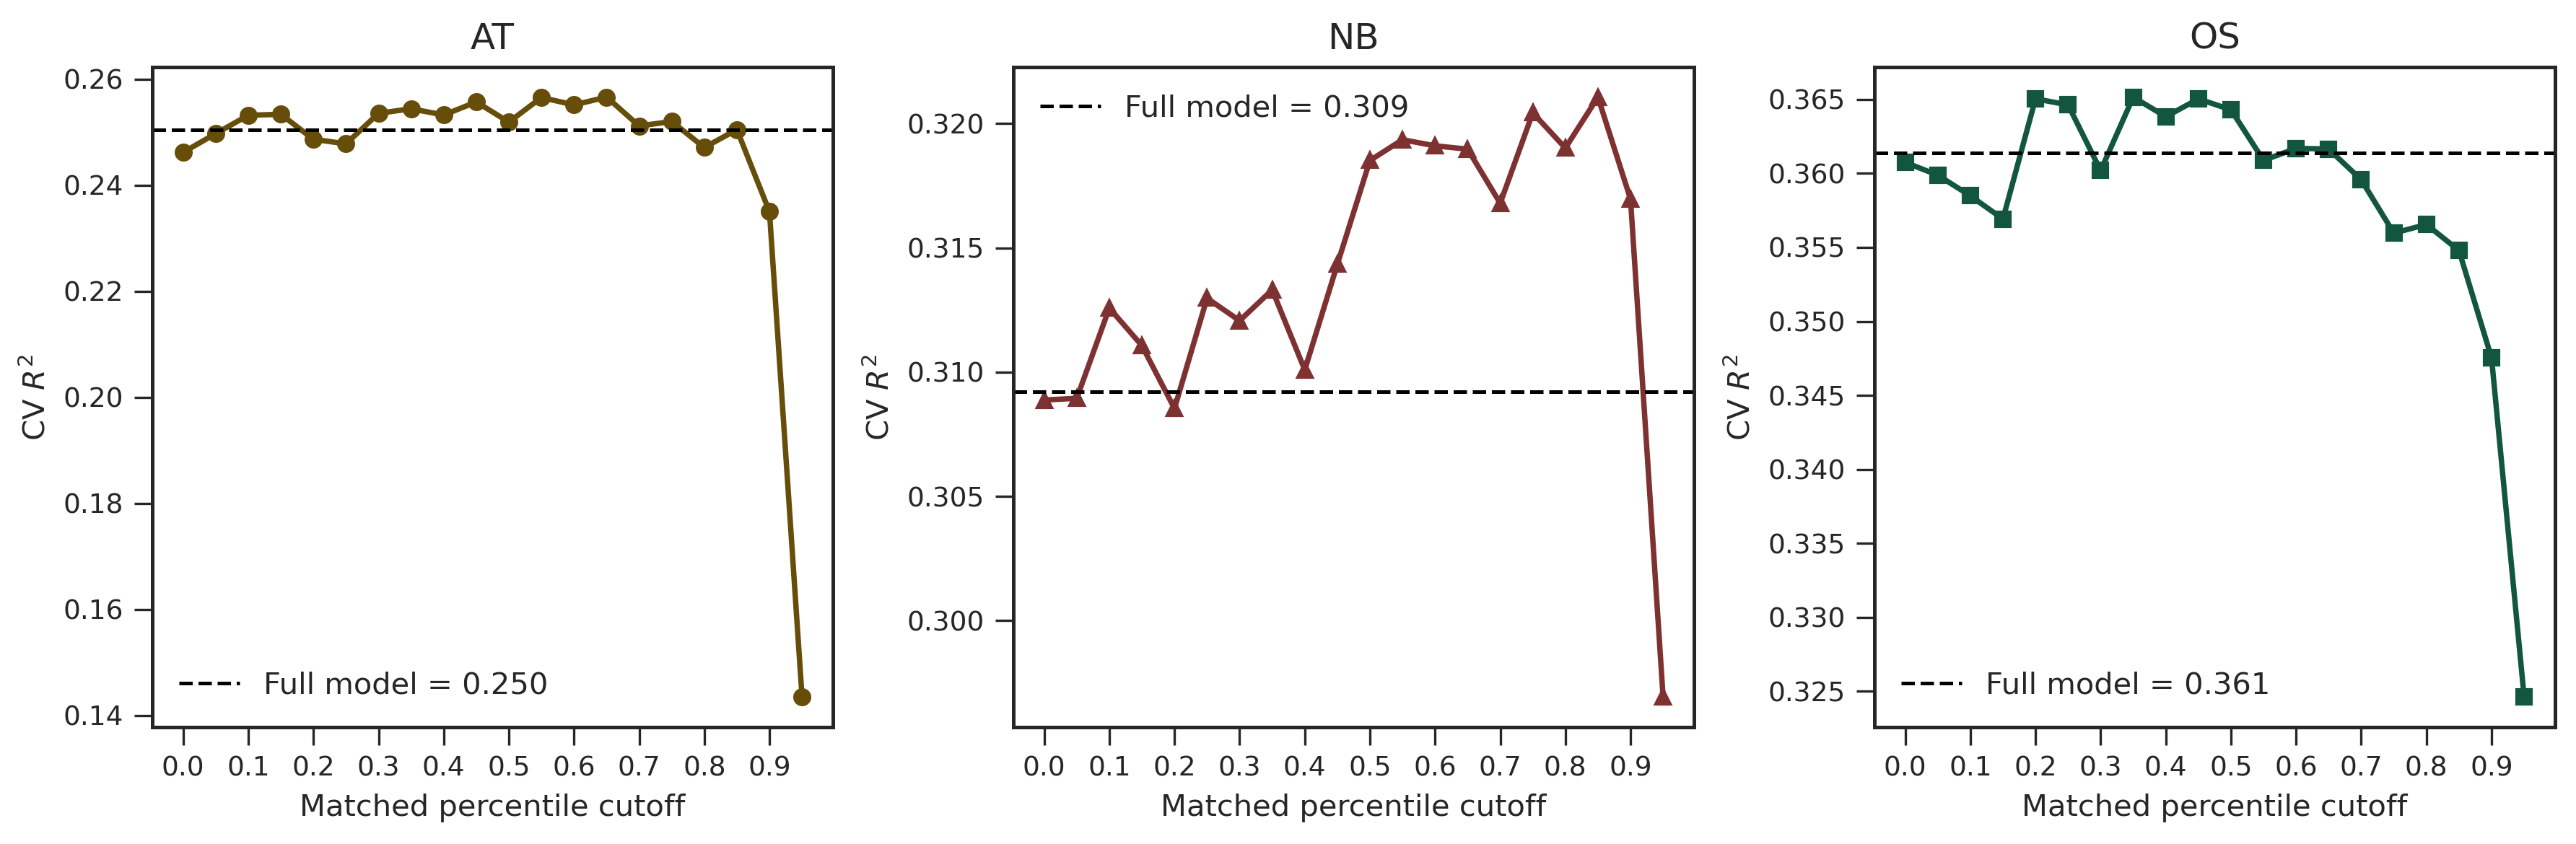

In [10]:
# ============================================
# Reduced-model CV R2 across cutoffs
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(12, 4), dpi=_PLOT_CFG["dpi"])

for ax, species_key in zip(axes, SPECIES):
    species = SPECIES_INFO[species_key]["label"]
    temp = retention_cv_df.loc[retention_cv_df["Species"] == species]
    full_r2 = temp["Full_CV_R2"].iloc[0]

    ax.plot(
        temp["Cutoff"], temp["Reduced_CV_R2"],
        color=SPECIES_INFO[species_key]["color"],
        marker=SPECIES_INFO[species_key]["marker"],
        lw=1.8, ms=5,
    )

    ax.axhline(full_r2, color="black", ls="--", lw=1.2, label=f"Full model = {full_r2:.3f}")

    ax.set_title(species)
    ax.set_xticks(np.arange(0, 1.0, 0.1))
    format_axis(ax, xlabel="Matched percentile cutoff", ylabel="CV $R^2$")
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()

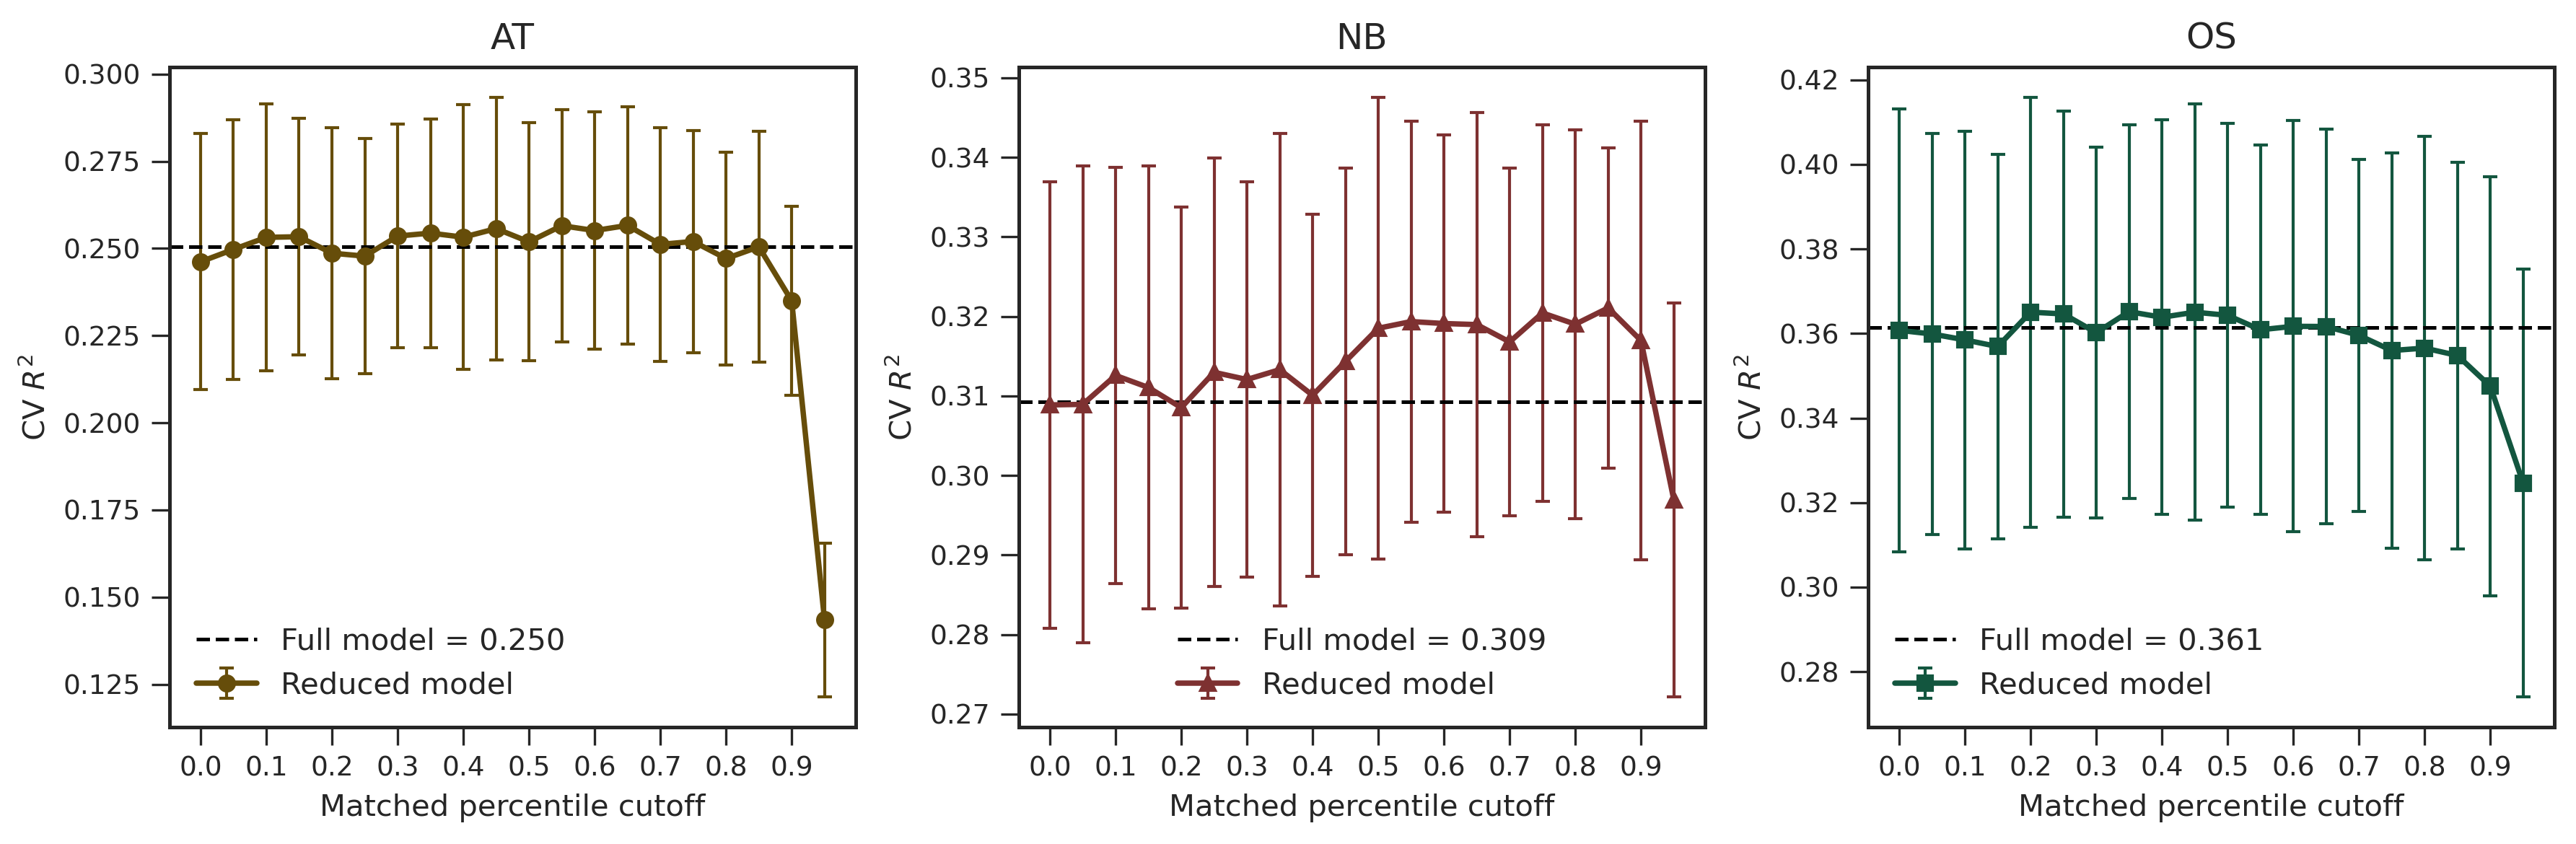

In [11]:
# ============================================
# Reduced-model CV R2 across cutoffs
# Mean ± SD across CV folds
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(12, 4), dpi=_PLOT_CFG["dpi"])

for ax, species_key in zip(axes, SPECIES):
    species = SPECIES_INFO[species_key]["label"]
    temp = retention_cv_df.loc[retention_cv_df["Species"] == species]
    full_r2 = temp["Full_CV_R2"].iloc[0]

    ax.errorbar(
        temp["Cutoff"], temp["Reduced_CV_R2"], yerr=temp["CV_R2_SD"],
        color=SPECIES_INFO[species_key]["color"], marker=SPECIES_INFO[species_key]["marker"],
        lw=1.8, ms=5, capsize=2.5, elinewidth=1, label="Reduced model",
    )

    ax.axhline(full_r2, color="black", ls="--", lw=1.2, label=f"Full model = {full_r2:.3f}")

    ax.set_title(species)
    ax.set_xticks(np.arange(0, 1.0, 0.1))
    format_axis(ax, xlabel="Matched percentile cutoff", ylabel="CV $R^2$")
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()

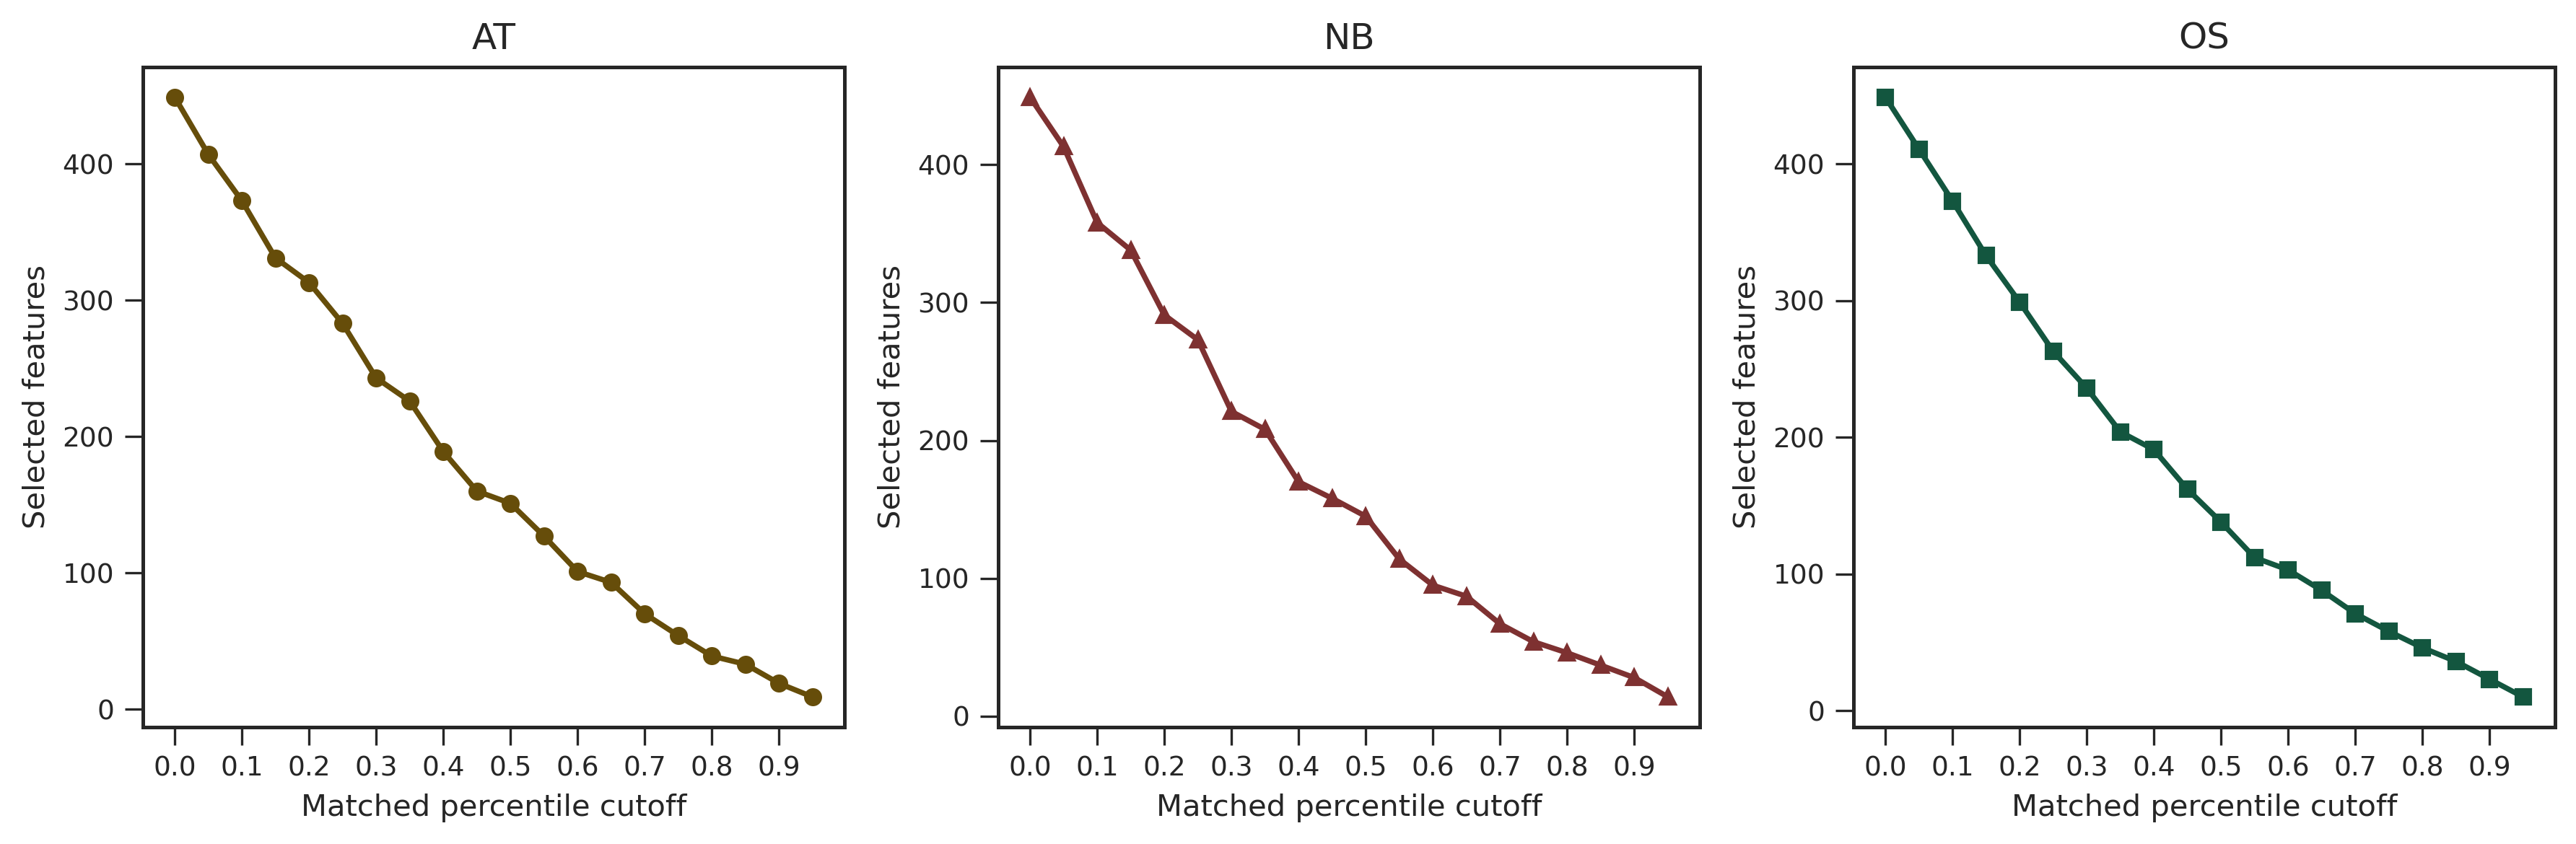

In [12]:
# ============================================
# Selected features across cutoffs
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(12, 4), dpi=_PLOT_CFG["dpi"])

for ax, species_key in zip(axes, SPECIES):
    species = SPECIES_INFO[species_key]["label"]
    temp = retention_cv_df.loc[retention_cv_df["Species"] == species]

    ax.plot(
        temp["Cutoff"], temp["N_features"],
        color=SPECIES_INFO[species_key]["color"],
        marker=SPECIES_INFO[species_key]["marker"],
        lw=1.8, ms=5,
    )

    ax.set_title(species)
    ax.set_xticks(np.arange(0, 1.0, 0.1))
    format_axis(ax, xlabel="Matched percentile cutoff", ylabel="Selected features")

plt.tight_layout()
plt.show()

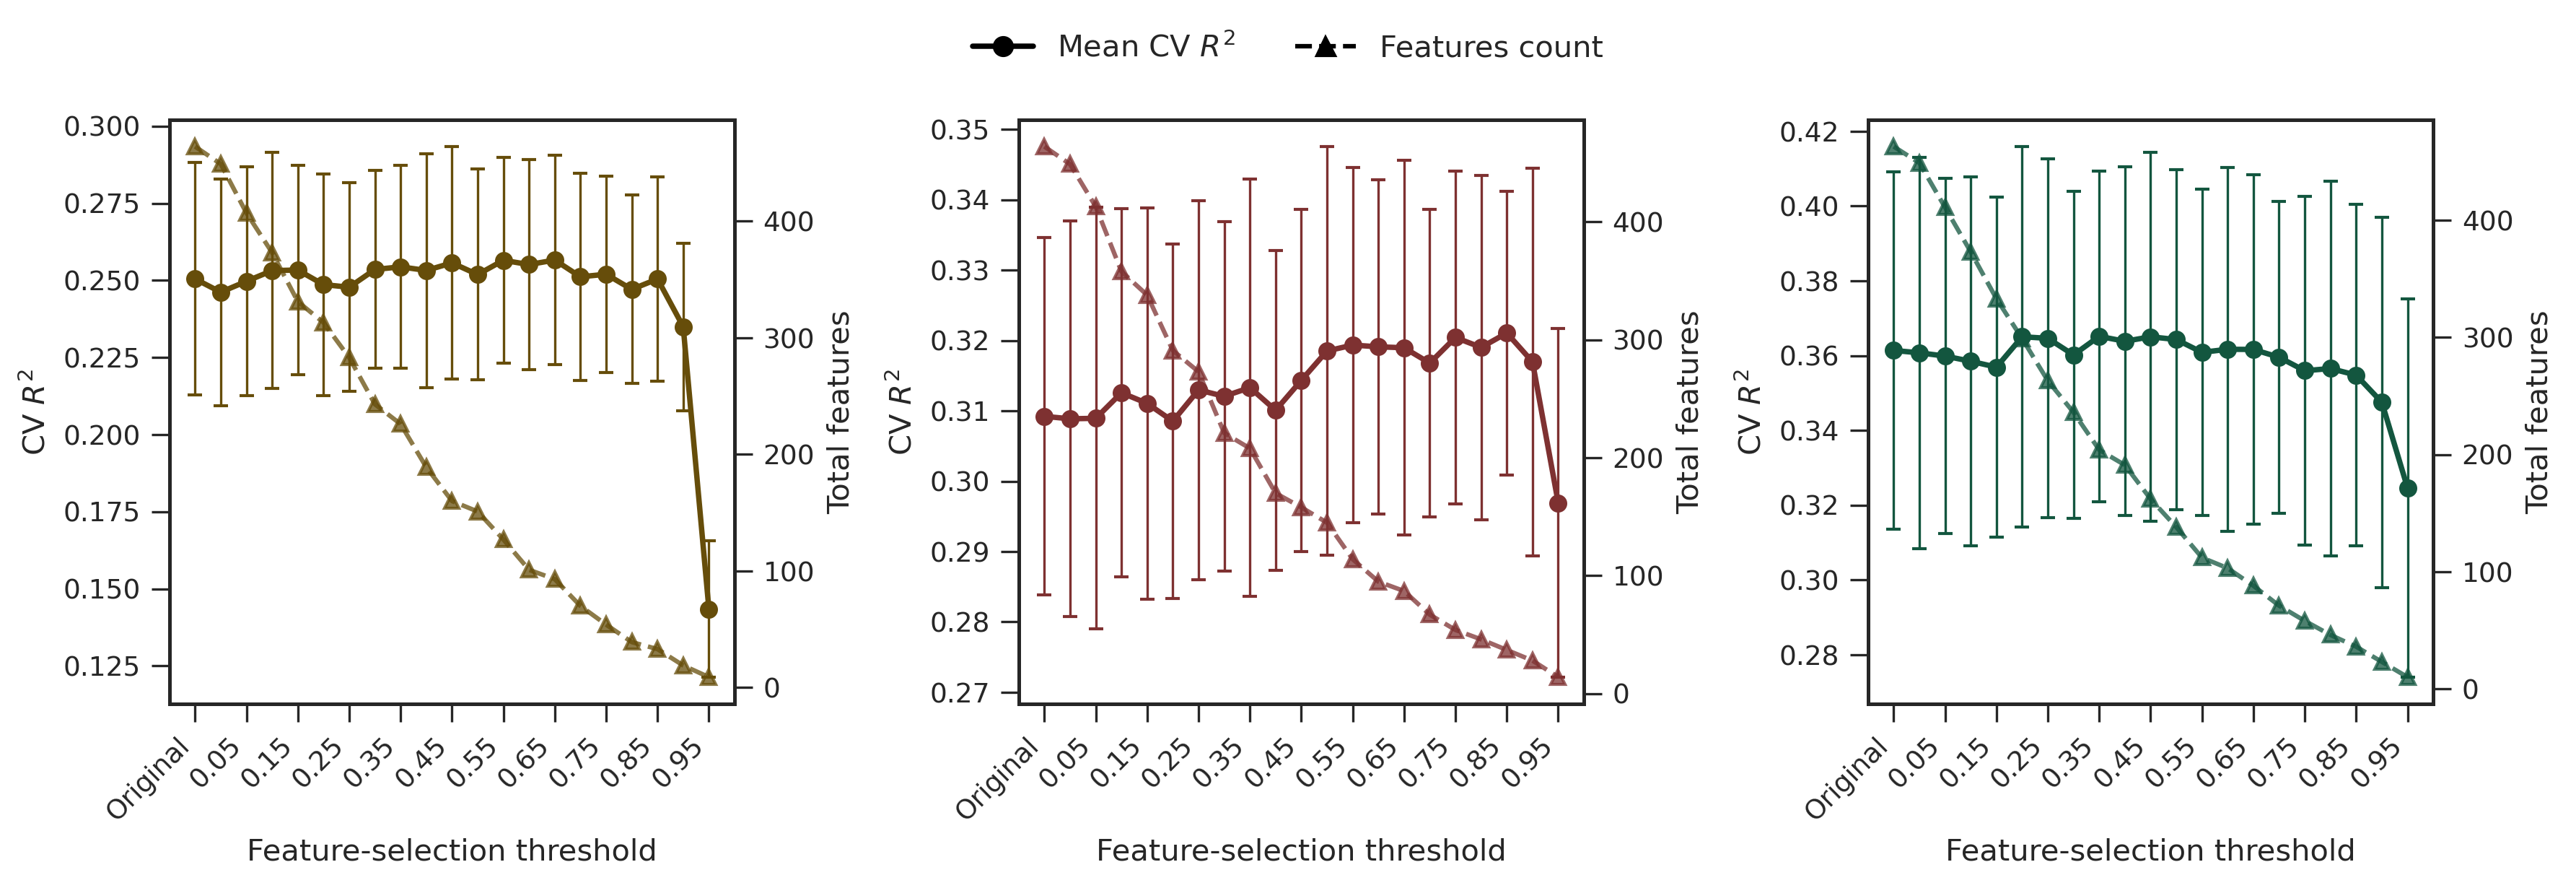

In [13]:
# ============================================
# Threshold-performance trade-off
# Original model + percentile thresholds
# ============================================

from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 3, figsize=(12, 4), dpi=_PLOT_CFG["dpi"])

for ax, species_key in zip(axes, SPECIES):
    species = SPECIES_INFO[species_key]["label"]
    color = SPECIES_INFO[species_key]["color"]
    temp = retention_cv_df.loc[retention_cv_df["Species"] == species].copy()

    x = np.arange(len(temp) + 1)
    labels = ["Original"] + [f"{c:.2f}" for c in temp["Cutoff"]]

    cv_r2 = np.r_[temp["Full_CV_R2"].iloc[0], temp["Reduced_CV_R2"]]
    cv_sd = np.r_[temp["Full_CV_R2_SD"].iloc[0], temp["CV_R2_SD"]]
    n_features = np.r_[len(lgbm_bundles[species_key]["feature_names"]), temp["N_features"]]

    ax.errorbar(
        x, cv_r2, yerr=cv_sd,
        color=color, marker="o", ls="-", lw=1.8, ms=5,
        capsize=2.5, elinewidth=0.8,
    )

    ax2 = ax.twinx()
    ax2.plot(
        x, n_features,
        color=color, marker="^", ls="--", lw=1.5, ms=5, alpha=0.75,
    )

    ax.set_xticks(x[::2])
    ax.set_xticklabels(np.array(labels)[::2], rotation=45, ha="right")

    format_axis(ax, xlabel="Feature-selection threshold", ylabel="CV $R^2$")
    format_axis(ax2, ylabel="Total features")

legend_handles = [
    Line2D([0], [0], color="black", marker="o", ls="-", lw=1.8, label="Mean CV $R^2$"),
    Line2D([0], [0], color="black", marker="^", ls="--", lw=1.5, label="Features count"),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),
    ncol=2,
    frameon=False,
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

In [14]:
# ============================================
# Cutoff decision summary
# ============================================

cutoff_summary_df = retention_cv_df.copy()

cutoff_summary_df["Feature_reduction_pct"] = 100 * (
    1 - cutoff_summary_df["N_features"] /
    cutoff_summary_df.groupby("Species")["N_features"].transform("first")
)

cutoff_summary_df["CV_R2_change"] = (
    cutoff_summary_df["Reduced_CV_R2"] -
    cutoff_summary_df["Full_CV_R2"]
)

cutoff_summary_df = cutoff_summary_df.loc[
    cutoff_summary_df["Cutoff"] >= 0.75,
    ["Species", "Cutoff", "N_features", "Feature_reduction_pct",
     "Full_CV_R2", "Reduced_CV_R2", "CV_R2_SD", "CV_R2_change"]
].reset_index(drop=True)

display(cutoff_summary_df.round(4))

,Species,Cutoff,N_features,Feature_reduction_pct,Full_CV_R2,Reduced_CV_R2,CV_R2_SD,CV_R2_change
0,AT,0.75,54,87.9733,0.2505,0.2520,0.0319,0.0015
1,AT,0.80,39,91.3140,0.2505,0.2471,0.0305,-0.0034
2,AT,0.85,33,92.6503,0.2505,0.2505,0.0331,-0.0000
3,AT,0.90,19,95.7684,0.2505,0.2350,0.0272,-0.0155
4,AT,0.95,9,97.9955,0.2505,0.1435,0.0221,-0.1070
5,NB,0.75,54,87.9733,0.3092,0.3204,0.0237,0.0112
6,NB,0.80,46,89.7550,0.3092,0.3190,0.0245,0.0098
7,NB,0.85,37,91.7595,0.3092,0.3211,0.0202,0.0118
8,NB,0.90,28,93.7639,0.3092,0.3170,0.0275,0.0077
9,NB,0.95,14,96.8820,0.3092,0.2969,0.0248,-0.0123


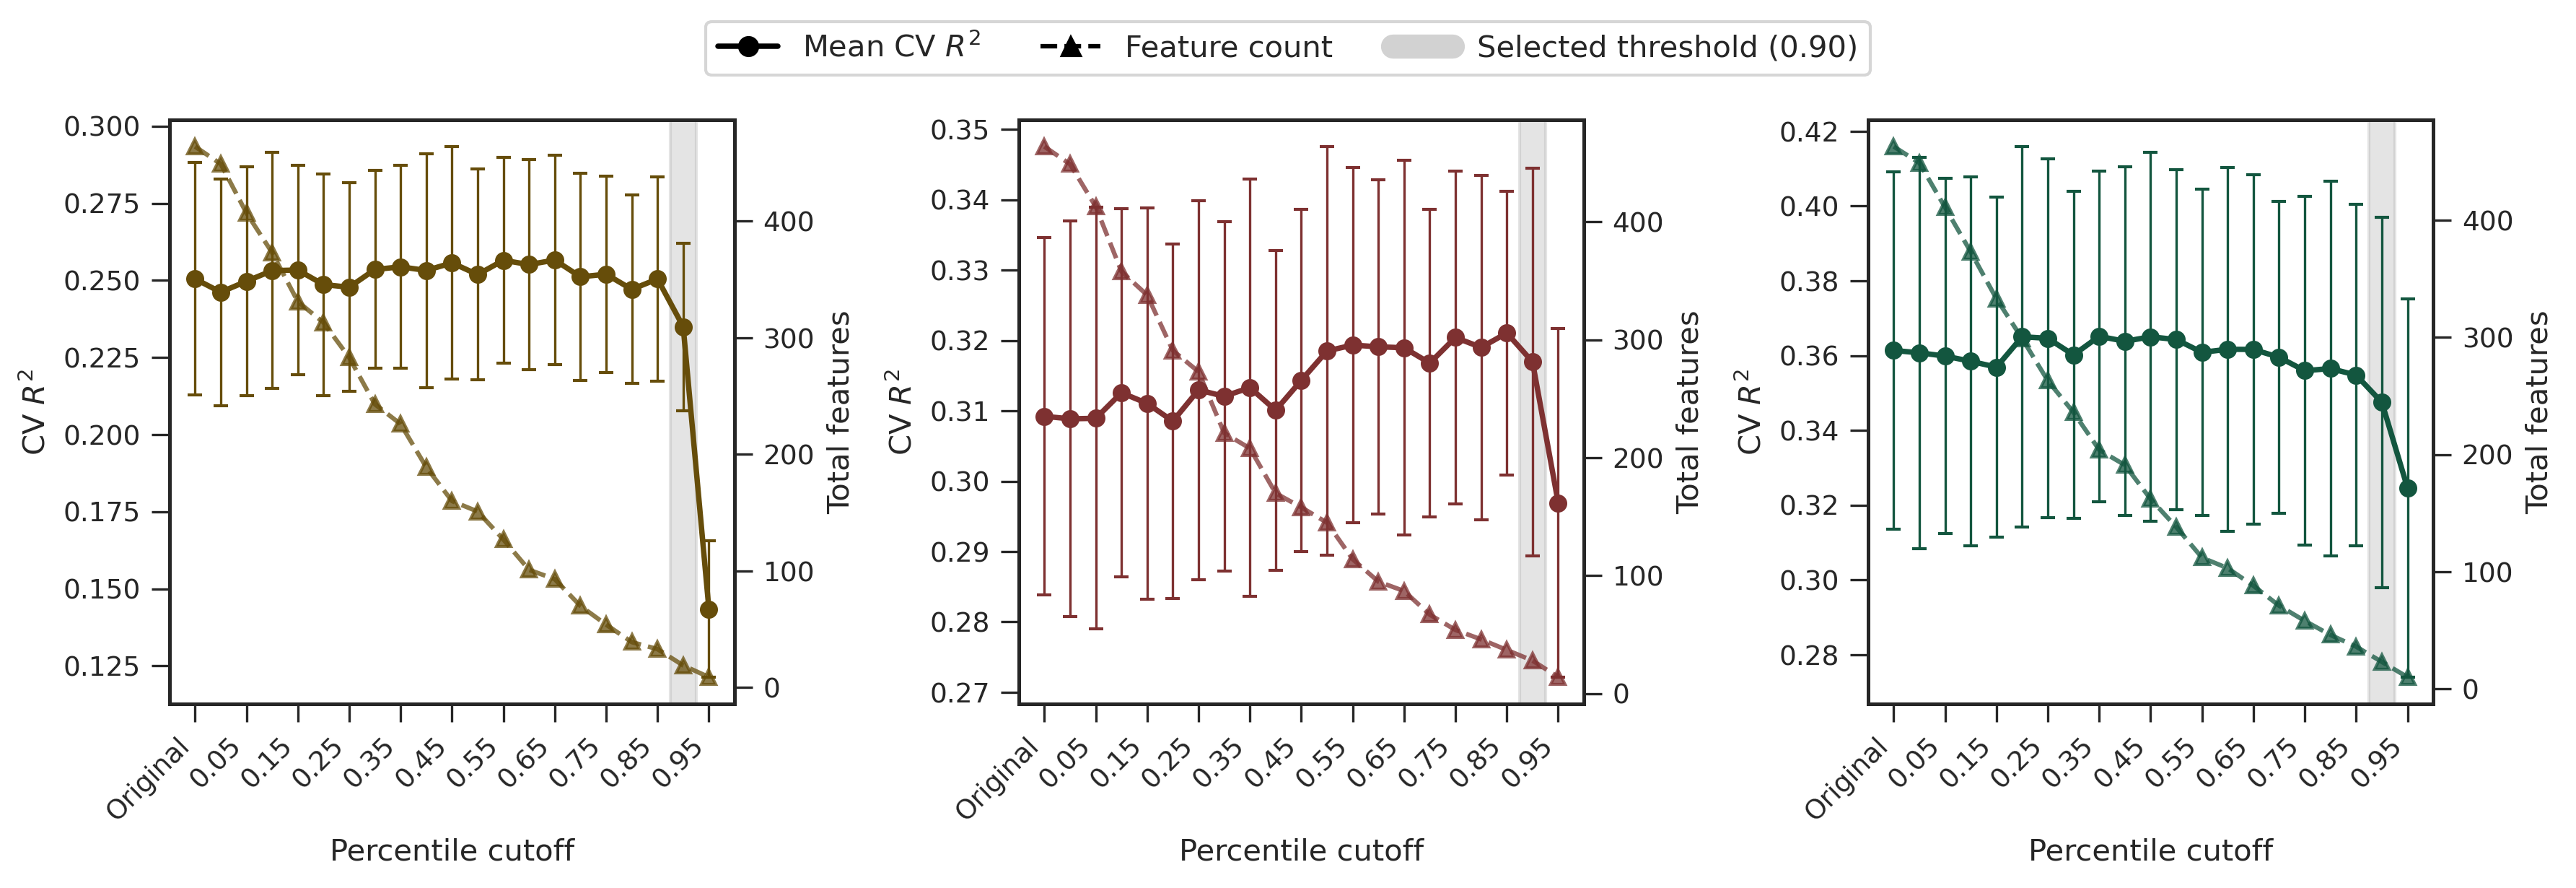

In [28]:
# ============================================
# Threshold-performance trade-off
# Original model + percentile thresholds
# ============================================

from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 3, figsize=(12, 4), dpi=_PLOT_CFG["dpi"])

for ax, species_key in zip(axes, SPECIES):
    species = SPECIES_INFO[species_key]["label"]
    color = SPECIES_INFO[species_key]["color"]
    temp = retention_cv_df.loc[retention_cv_df["Species"] == species].copy()

    x = np.arange(len(temp) + 1)
    labels = ["Original"] + [f"{c:.2f}" for c in temp["Cutoff"]]
    cv_r2 = np.r_[temp["Full_CV_R2"].iloc[0], temp["Reduced_CV_R2"]]
    cv_sd = np.r_[temp["Full_CV_R2_SD"].iloc[0], temp["CV_R2_SD"]]
    n_features = np.r_[len(lgbm_bundles[species_key]["feature_names"]), temp["N_features"]]

    ax.errorbar(
        x, cv_r2, yerr=cv_sd, color=color, marker="o", ls="-",
        lw=1.8, ms=5, capsize=2.5, elinewidth=0.8, zorder=3,
    )

    ax2 = ax.twinx()
    ax2.plot(
        x, n_features, color=color, marker="^", ls="--",
        lw=1.5, ms=5, alpha=0.75, zorder=2,
    )

    selected = labels.index("0.90")
    ax.axvspan(selected - 0.5, selected + 0.5, color="0.7", alpha=0.35, zorder=0)
    
    ax.set_xticks(x[::2])
    ax.set_xticklabels(np.array(labels)[::2], rotation=45, ha="right")

    format_axis(ax, xlabel="Percentile cutoff", ylabel="CV $R^2$")
    format_axis(ax2, ylabel="Total features")

legend_handles = [
    Line2D([0], [0], color="black", marker="o", ls="-", lw=1.8, label="Mean CV $R^2$"),
    Line2D([0], [0], color="black", marker="^", ls="--", lw=1.5, label="Feature count"),
    Line2D([0], [0], color="0.5", lw=8, alpha=0.35, label="Selected threshold (0.90)"),
]

fig.legend(
    handles=legend_handles, loc="upper center",
    bbox_to_anchor=(0.5, 1.03), ncol=3, frameon=True,
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

In [16]:
# ============================================
# Load screening feature table
# ============================================

SCREENING_FILE = LGBM_DIR / "lgbm.screening_feature_table.tsv.gz"

screening_df = pd.read_csv(SCREENING_FILE, sep="\t")

print(screening_df.shape)
print(screening_df.columns.tolist())
display(screening_df.head())

(1347, 10)
['Feature', 'Region', 'Feature_type', 'SSS', 'Delta', 'Species', 'Importance_normalized', 'Importance_percentile', 'SSS_percentile', 'Enrichment']


,Feature,Region,Feature_type,SSS,Delta,Species,Importance_normalized,Importance_percentile,SSS_percentile,Enrichment
0,3'UTR.A-freq,3'UTR,Nucleotide_kmer_freq,0.002228,-0.001200,AT,0.001579,0.359688,0.659243,Depleted
1,3'UTR.AA-freq,3'UTR,Nucleotide_kmer_freq,0.002280,0.001081,AT,0.003684,0.863029,0.672606,Enriched
2,3'UTR.AAA-freq,3'UTR,Nucleotide_kmer_freq,0.002856,-0.001981,AT,0.000789,0.138085,0.781737,Depleted
3,3'UTR.AAC-freq,3'UTR,Nucleotide_kmer_freq,0.002329,0.001617,AT,0.003684,0.863029,0.689310,Enriched
4,3'UTR.AAG-freq,3'UTR,Nucleotide_kmer_freq,0.001495,0.000599,AT,0.002895,0.743875,0.440980,Enriched


In [17]:
# ============================================
# FI × SSS cutoff grid
# Reduced-model CV performance
# ============================================

cutoffs = np.arange(0.00, 1.00, 0.05)
grid_rows = []

for species_key in SPECIES:
    species = SPECIES_INFO[species_key]["label"]
    bundle = lgbm_bundles[species_key]
    x_train, y_train = bundle["x_train_model"], bundle["y_train_model"]

    saved = best_params[species_key]
    params = {
        "max_depth": int(saved["max_depth"]),
        "min_child_samples": int(saved["min_child_samples"]),
        "feature_fraction": float(saved["feature_fraction"]),
        "num_leaves": int(saved["num_leaves"]),
    }

    cv = model_selection.KFold(n_splits=int(saved["k_cv"]), shuffle=True, random_state=0)

    for fi_cutoff in cutoffs:
        for sss_cutoff in cutoffs:
            features = screening_df.loc[
                (screening_df["Species"] == species) &
                (screening_df["Importance_percentile"] >= fi_cutoff) &
                (screening_df["SSS_percentile"] >= sss_cutoff),
                "Feature",
            ].tolist()

            features = [f for f in features if f in x_train.columns]

            if not features:
                grid_rows.append({
                    "Species": species, "FI_cutoff": fi_cutoff, "SSS_cutoff": sss_cutoff,
                    "N_features": 0, "CV_R2": np.nan, "CV_R2_SD": np.nan,
                })
                continue

            model = LGBMRegressor(
                objective="regression", n_estimators=int(saved["n_estimators"]),
                learning_rate=float(saved["learning_rate"]), random_state=0,
                n_jobs=1, verbosity=-1, **params,
            )

            scores = model_selection.cross_val_score(
                model, x_train[features], y_train,
                cv=cv, scoring="r2", n_jobs=10,
            )

            grid_rows.append({
                "Species": species, "FI_cutoff": fi_cutoff, "SSS_cutoff": sss_cutoff,
                "N_features": len(features), "CV_R2": scores.mean(),
                "CV_R2_SD": scores.std(ddof=1),
            })

cutoff_grid_cv_df = (
    pd.DataFrame(grid_rows)
    .sort_values(["Species", "FI_cutoff", "SSS_cutoff"])
    .reset_index(drop=True)
)

print("FI × SSS cutoff grid")
print(cutoff_grid_cv_df.shape)
display(cutoff_grid_cv_df.head())

FI × SSS cutoff grid
(1200, 6)


,Species,FI_cutoff,SSS_cutoff,N_features,CV_R2,CV_R2_SD
0,AT,0.0,0.00,449,0.246176,0.036747
1,AT,0.0,0.05,427,0.247811,0.037782
2,AT,0.0,0.10,405,0.250809,0.035531
3,AT,0.0,0.15,382,0.250355,0.036821
4,AT,0.0,0.20,360,0.247650,0.037175


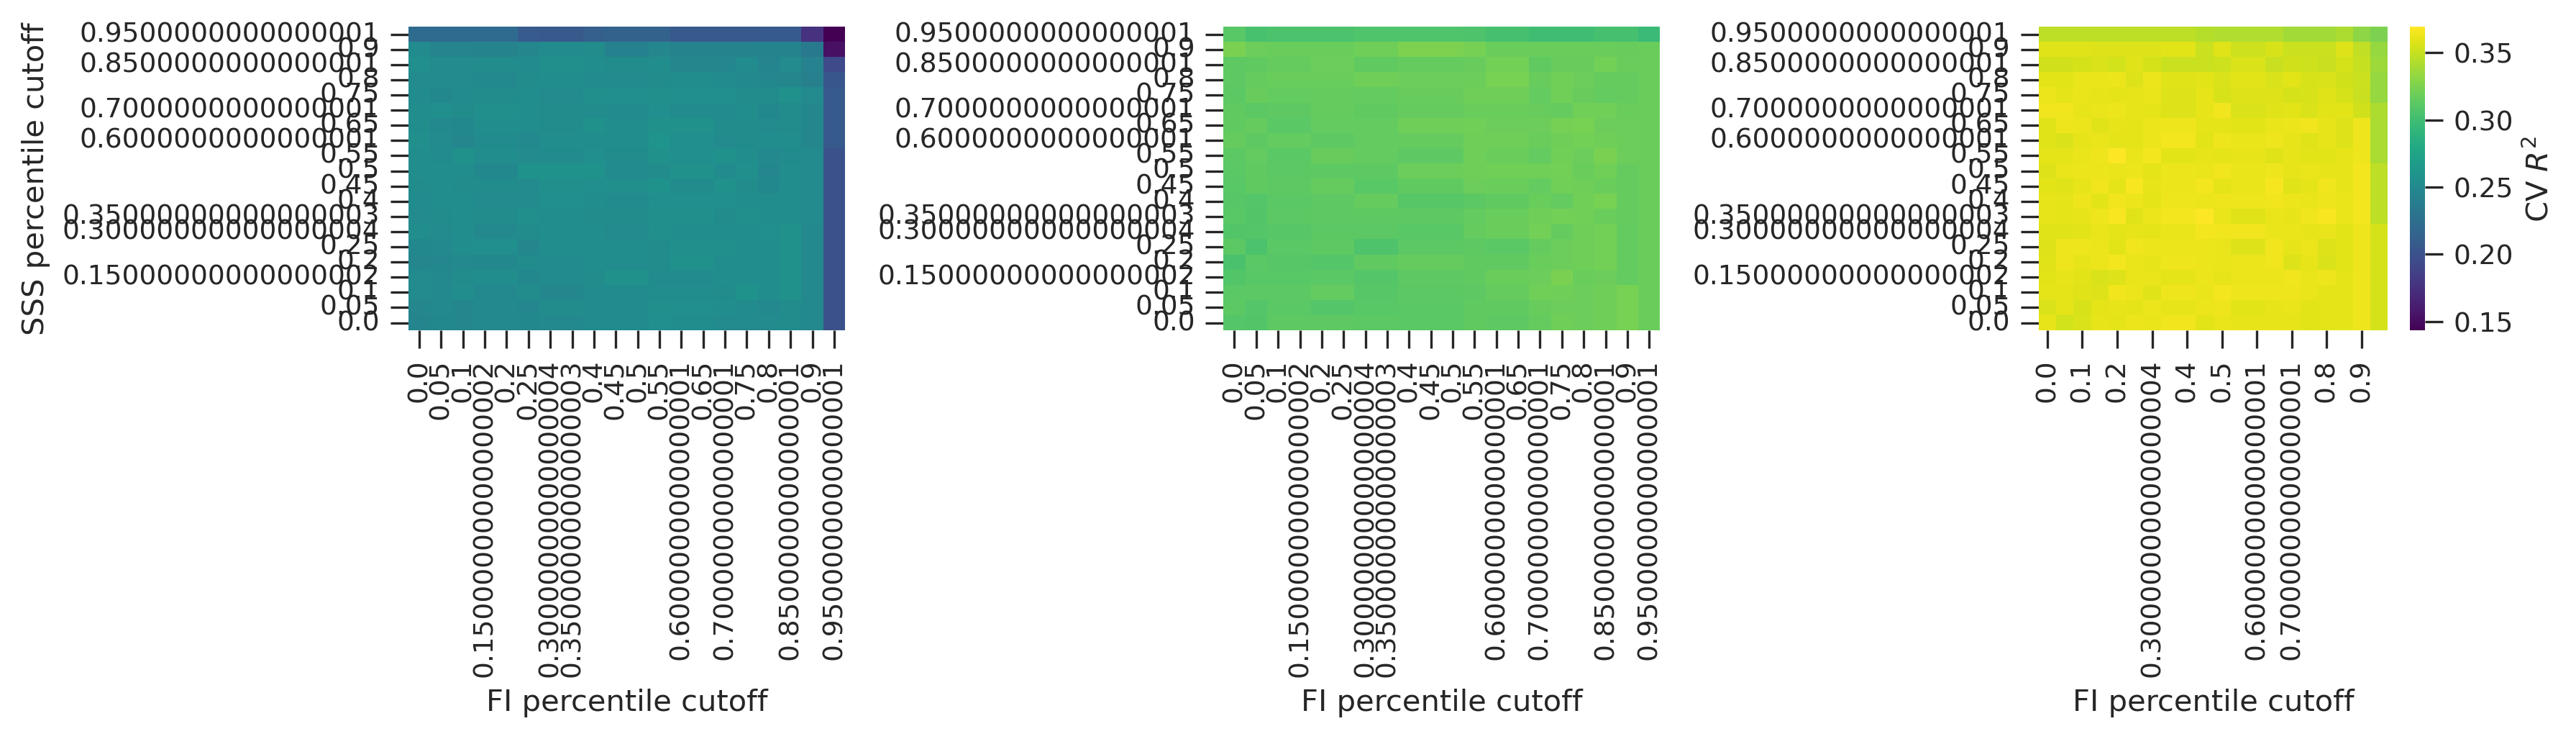

In [18]:
# ============================================
# FI × SSS cutoff landscape
# CV R2
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), dpi=_PLOT_CFG["dpi"])

for ax, species_key in zip(axes, SPECIES):
    species = SPECIES_INFO[species_key]["label"]
    temp = cutoff_grid_cv_df.loc[cutoff_grid_cv_df["Species"] == species]

    mat = (
        temp.pivot(index="SSS_cutoff", columns="FI_cutoff", values="CV_R2")
        .sort_index(ascending=False)
    )

    sns.heatmap(
        mat, cmap="viridis", ax=ax, vmin=cutoff_grid_cv_df["CV_R2"].min(),
        vmax=cutoff_grid_cv_df["CV_R2"].max(), cbar=ax is axes[-1],
        cbar_kws={"label": "CV $R^2$"} if ax is axes[-1] else None,
    )

    ax.set_xlabel("FI percentile cutoff")
    ax.set_ylabel("SSS percentile cutoff" if ax is axes[0] else "")

plt.tight_layout()
plt.show()

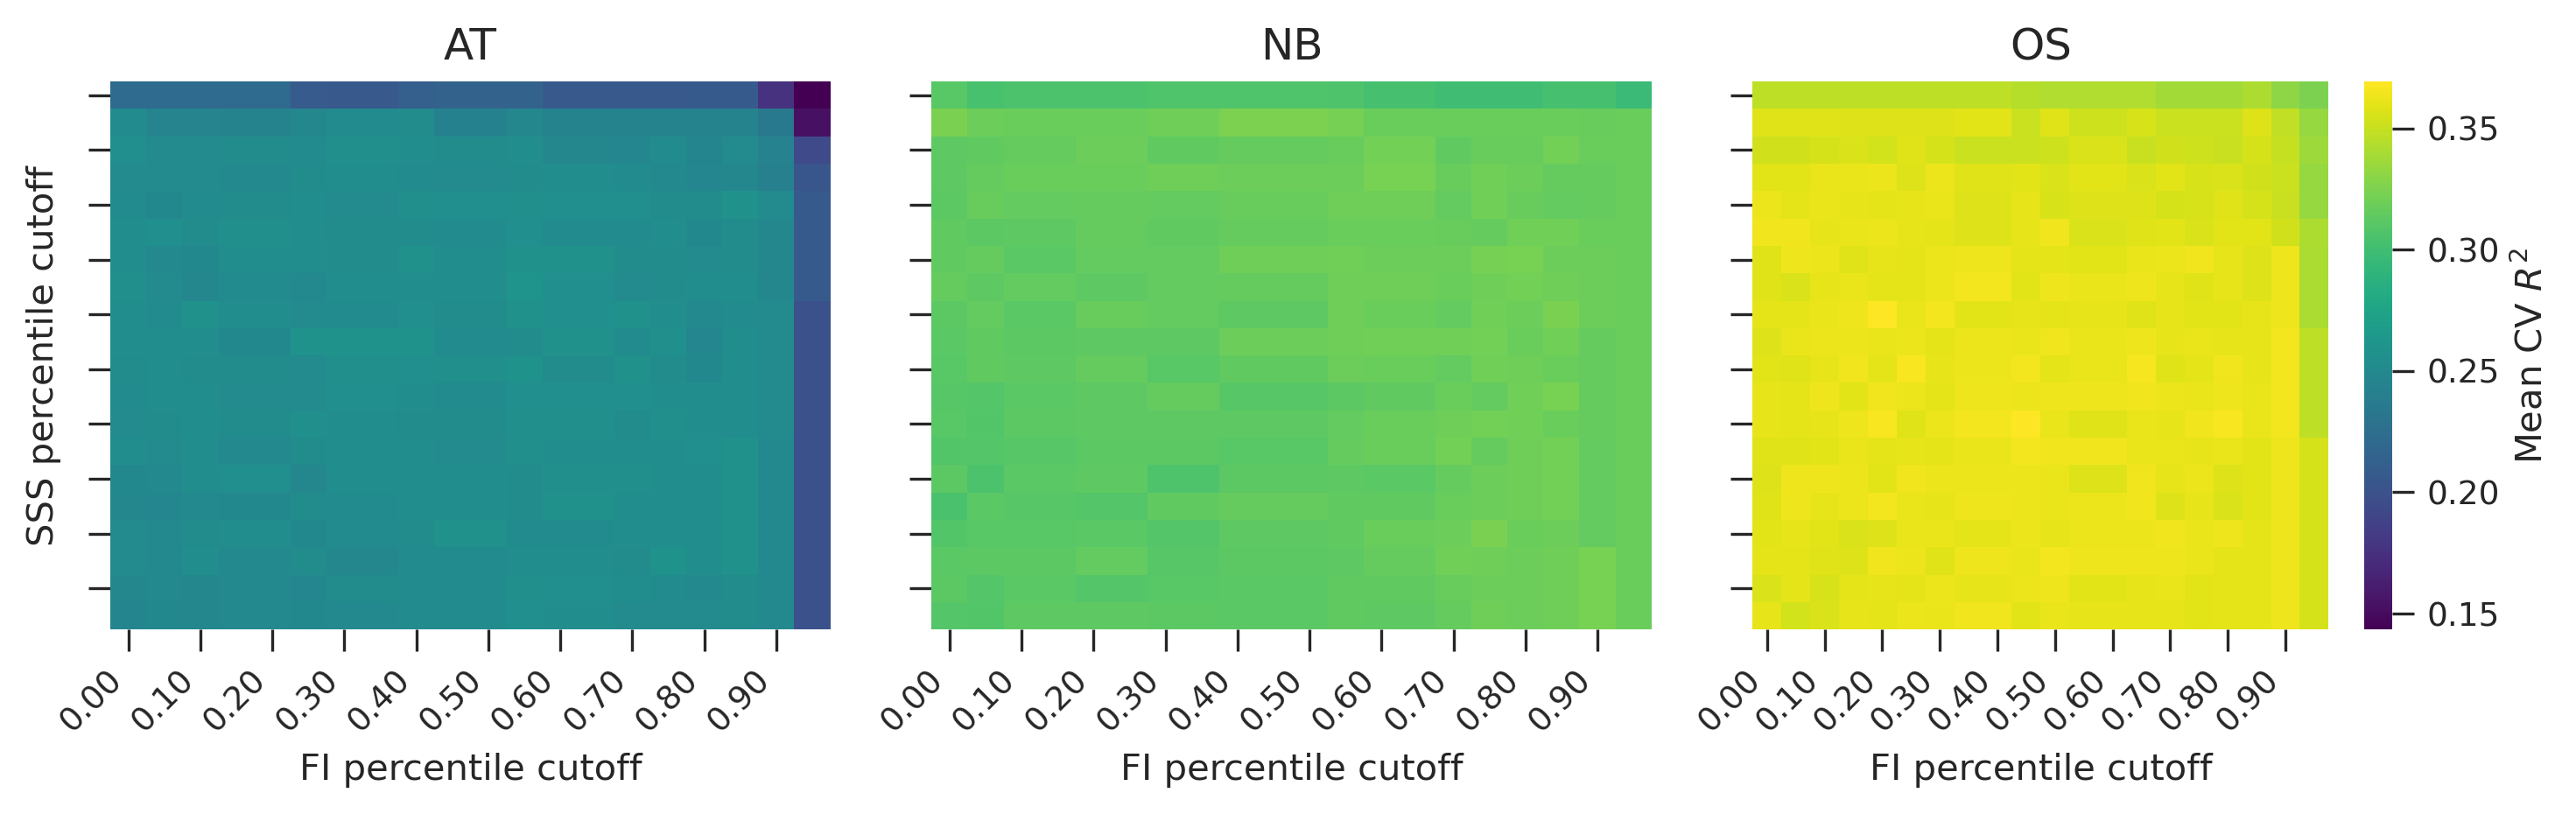

In [19]:
# ============================================
# FI × SSS cutoff landscape
# Predictive performance
# ============================================

cutoff_grid_cv_df["FI_cutoff"] = cutoff_grid_cv_df["FI_cutoff"].round(2)
cutoff_grid_cv_df["SSS_cutoff"] = cutoff_grid_cv_df["SSS_cutoff"].round(2)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.2), dpi=_PLOT_CFG["dpi"], sharex=True, sharey=True)
vmin, vmax = cutoff_grid_cv_df["CV_R2"].min(), cutoff_grid_cv_df["CV_R2"].max()

for ax, species_key in zip(axes, SPECIES):
    species = SPECIES_INFO[species_key]["label"]
    temp = cutoff_grid_cv_df.loc[cutoff_grid_cv_df["Species"] == species]
    mat = temp.pivot(index="SSS_cutoff", columns="FI_cutoff", values="CV_R2").sort_index(ascending=False)

    sns.heatmap(mat, cmap="viridis", vmin=vmin, vmax=vmax, ax=ax, cbar=ax is axes[-1],
                cbar_kws={"label": "Mean CV $R^2$"} if ax is axes[-1] else None)

    ax.set_title(species)
    ax.set_xlabel("FI percentile cutoff")
    ax.set_ylabel("SSS percentile cutoff" if ax is axes[0] else "")
    ax.set_xticklabels([f"{float(x.get_text()):.2f}" for x in ax.get_xticklabels()], rotation=45, ha="right")
    ax.set_yticklabels([f"{float(y.get_text()):.2f}" for y in ax.get_yticklabels()], rotation=0)

plt.tight_layout()
plt.show()

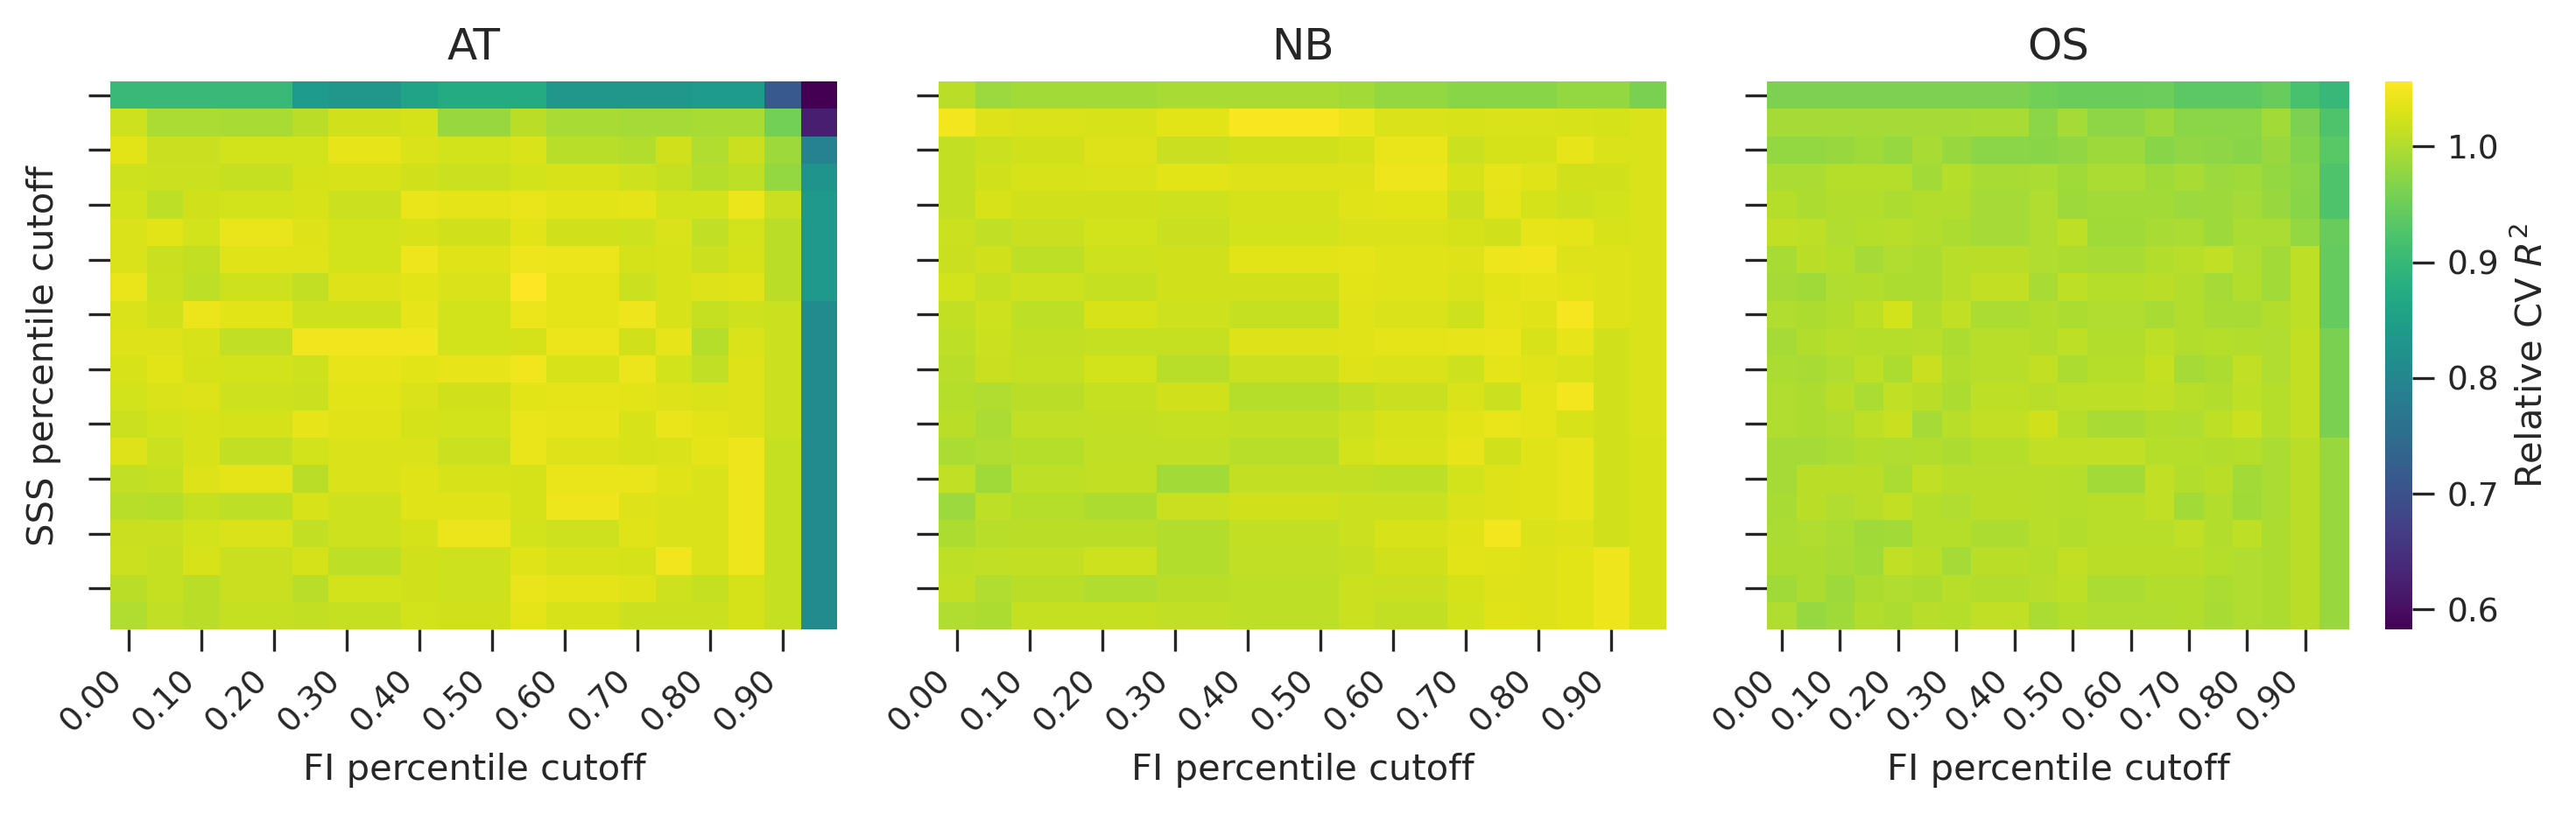

In [21]:
# ============================================
# FI × SSS cutoff landscape
# Relative predictive performance
# ============================================

cutoff_grid_cv_df["FI_cutoff"] = cutoff_grid_cv_df["FI_cutoff"].round(2)
cutoff_grid_cv_df["SSS_cutoff"] = cutoff_grid_cv_df["SSS_cutoff"].round(2)

baseline = cutoff_grid_cv_df.loc[
    (cutoff_grid_cv_df["FI_cutoff"] == 0) & (cutoff_grid_cv_df["SSS_cutoff"] == 0),
    ["Species", "CV_R2"],
].set_index("Species")["CV_R2"]

cutoff_grid_cv_df["Relative_CV_R2"] = cutoff_grid_cv_df["CV_R2"] / cutoff_grid_cv_df["Species"].map(baseline)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.2), dpi=_PLOT_CFG["dpi"], sharex=True, sharey=True)
vmin, vmax = cutoff_grid_cv_df["Relative_CV_R2"].min(), cutoff_grid_cv_df["Relative_CV_R2"].max()

for ax, species_key in zip(axes, SPECIES):
    species = SPECIES_INFO[species_key]["label"]
    temp = cutoff_grid_cv_df.loc[cutoff_grid_cv_df["Species"] == species]
    mat = temp.pivot(index="SSS_cutoff", columns="FI_cutoff", values="Relative_CV_R2").sort_index(ascending=False)

    sns.heatmap(
        mat, cmap="viridis", vmin=vmin, vmax=vmax, ax=ax, cbar=ax is axes[-1],
        cbar_kws={"label": "Relative CV $R^2$"} if ax is axes[-1] else None,
    )

    ax.set_title(species)
    ax.set_xlabel("FI percentile cutoff")
    ax.set_ylabel("SSS percentile cutoff" if ax is axes[0] else "")
    ax.set_xticklabels([f"{float(x.get_text()):.2f}" for x in ax.get_xticklabels()], rotation=45, ha="right")
    ax.set_yticklabels([f"{float(y.get_text()):.2f}" for y in ax.get_yticklabels()], rotation=0)

plt.tight_layout()
plt.show()

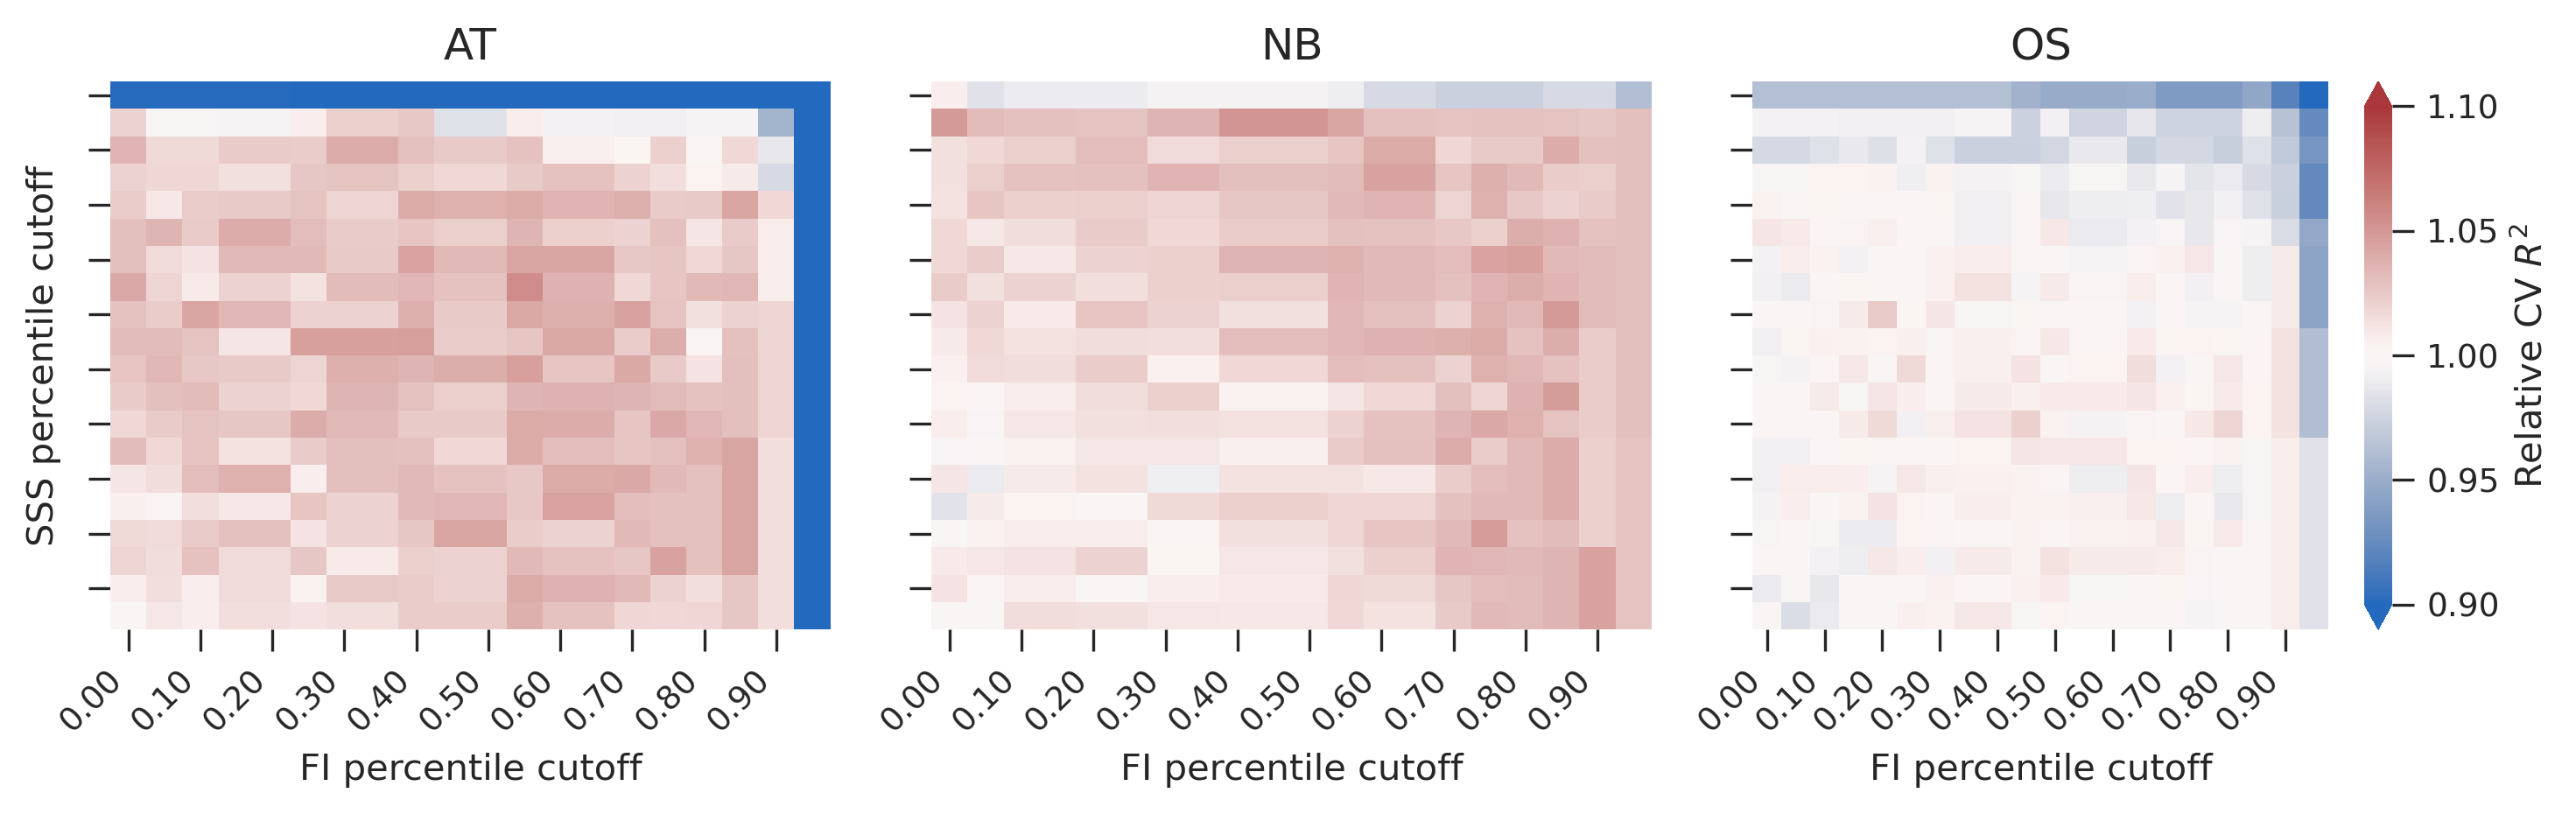

In [23]:
# ============================================
# FI × SSS cutoff landscape
# Relative predictive performance
# ============================================

cutoff_grid_cv_df["FI_cutoff"] = cutoff_grid_cv_df["FI_cutoff"].round(2)
cutoff_grid_cv_df["SSS_cutoff"] = cutoff_grid_cv_df["SSS_cutoff"].round(2)

baseline = cutoff_grid_cv_df.loc[
    (cutoff_grid_cv_df["FI_cutoff"] == 0) & (cutoff_grid_cv_df["SSS_cutoff"] == 0),
    ["Species", "CV_R2"],
].set_index("Species")["CV_R2"]

cutoff_grid_cv_df["Relative_CV_R2"] = cutoff_grid_cv_df["CV_R2"] / cutoff_grid_cv_df["Species"].map(baseline)

vmin, vmax = 0.90, 1.10
fig, axes = plt.subplots(1, 3, figsize=(10, 3.2), dpi=_PLOT_CFG["dpi"], sharex=True, sharey=True)

for ax, species_key in zip(axes, SPECIES):
    species = SPECIES_INFO[species_key]["label"]
    temp = cutoff_grid_cv_df.loc[cutoff_grid_cv_df["Species"] == species]
    mat = temp.pivot(index="SSS_cutoff", columns="FI_cutoff", values="Relative_CV_R2").sort_index(ascending=False)

    sns.heatmap(
        mat, cmap="vlag", center=1, vmin=vmin, vmax=vmax, ax=ax,
        cbar=ax is axes[-1], cbar_kws={"label": "Relative CV $R^2$", "extend": "both"} if ax is axes[-1] else None,
    )

    ax.set_title(species)
    ax.set_xlabel("FI percentile cutoff")
    ax.set_ylabel("SSS percentile cutoff" if ax is axes[0] else "")
    ax.set_xticklabels([f"{float(x.get_text()):.2f}" for x in ax.get_xticklabels()], rotation=45, ha="right")
    ax.set_yticklabels([f"{float(y.get_text()):.2f}" for y in ax.get_yticklabels()], rotation=0)

plt.tight_layout()
plt.show()

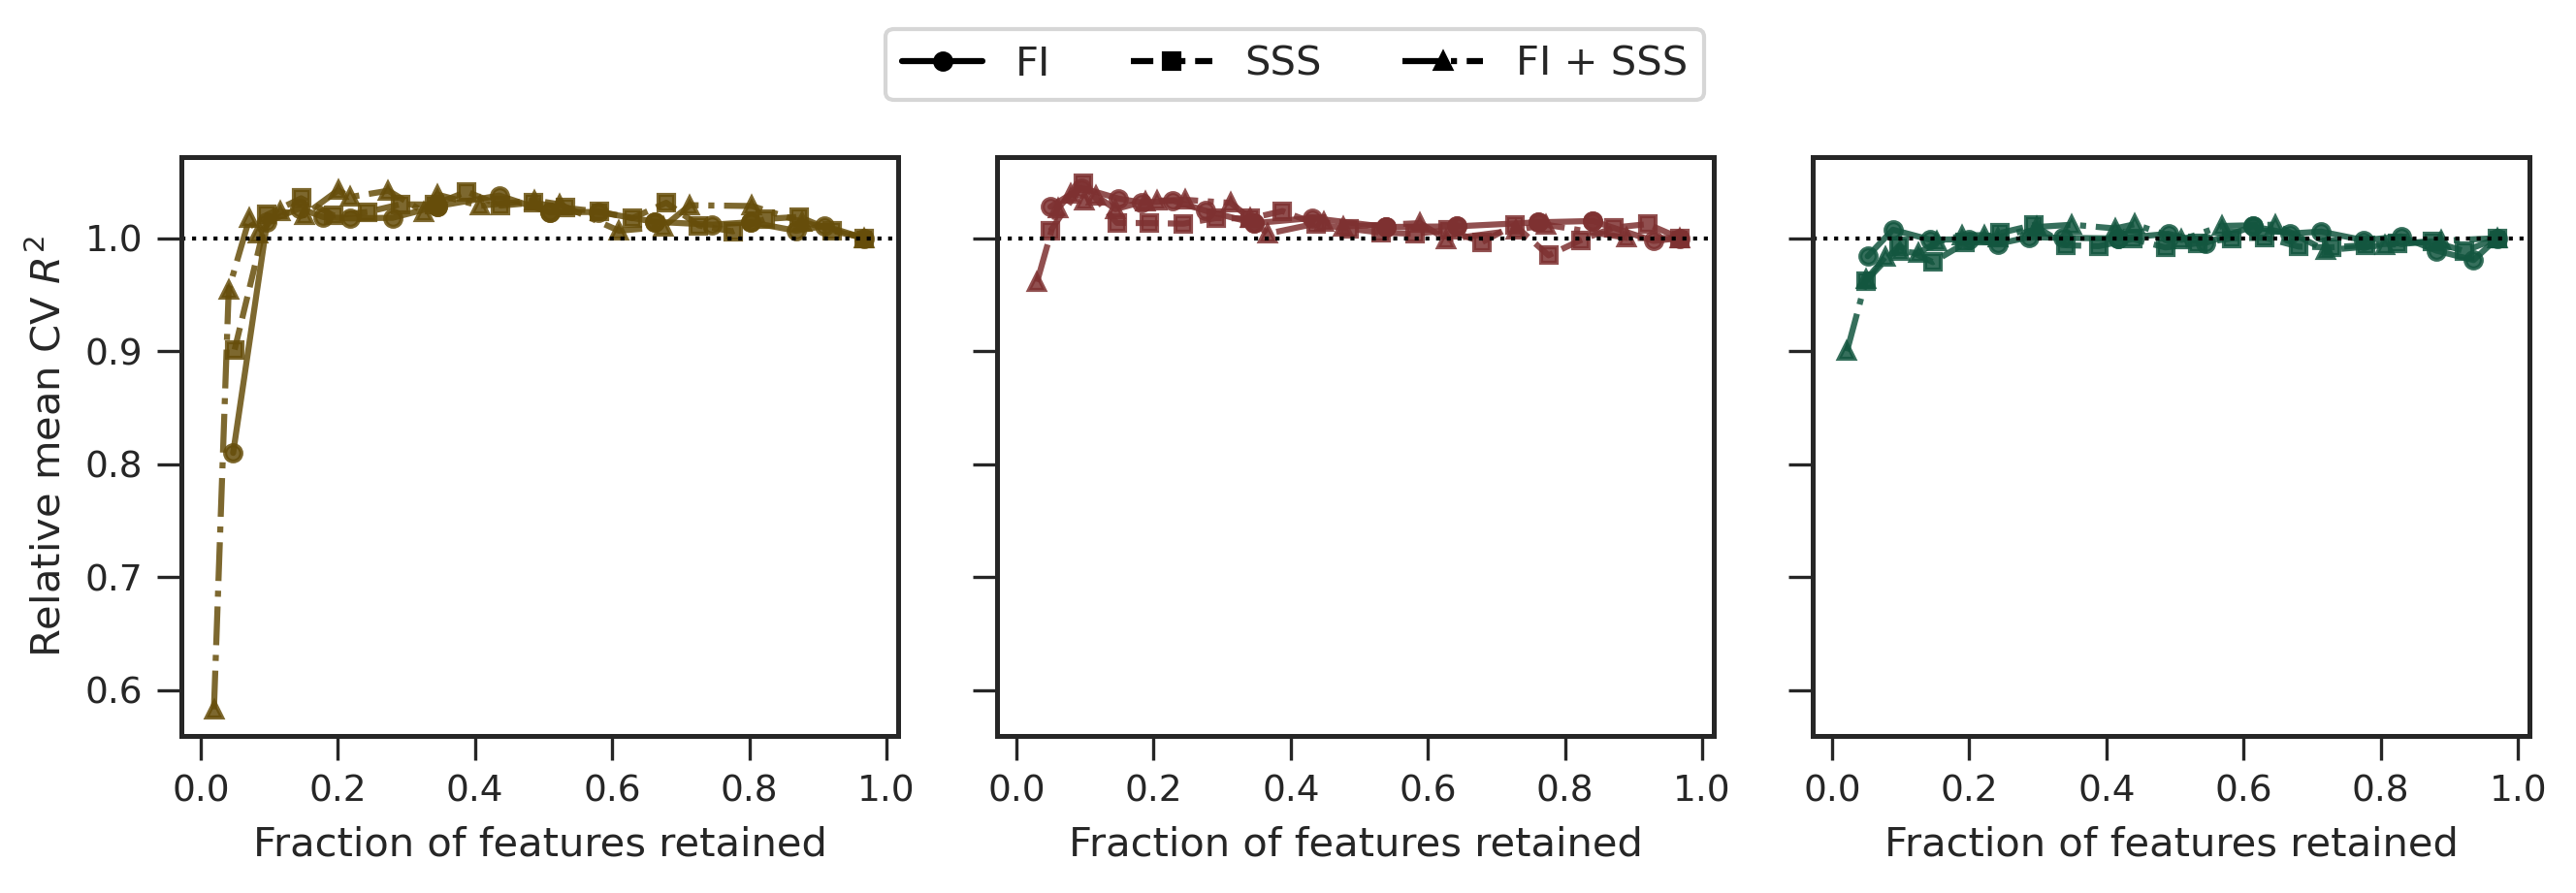

In [33]:
# ============================================
# FI-only vs SSS-only vs joint screening
# ============================================

from matplotlib.lines import Line2D

baseline_r2 = cutoff_grid_cv_df.query(
    "FI_cutoff == 0 and SSS_cutoff == 0"
).set_index("Species")["CV_R2"]

baseline_n = {
    SPECIES_INFO[k]["label"]: len(lgbm_bundles[k]["feature_names"])
    for k in SPECIES
}

paths = {
    "FI":       lambda d: np.isclose(d["SSS_cutoff"], 0),
    "SSS":      lambda d: np.isclose(d["FI_cutoff"], 0),
    "FI + SSS": lambda d: np.isclose(d["FI_cutoff"], d["SSS_cutoff"]),
}

rows = []
for species in ["AT", "NB", "OS"]:
    d = cutoff_grid_cv_df.query("Species == @species")
    for strategy, mask in paths.items():
        p = d.loc[mask(d)].copy()
        p["Strategy"] = strategy
        p["Relative_CV_R2"] = p["CV_R2"] / baseline_r2[species]
        p["Fraction_retained"] = p["N_features"] / baseline_n[species]
        rows.append(p)

strategy_df = pd.concat(rows, ignore_index=True)

style = {"FI": ("o", "-"), "SSS": ("s", "--"), "FI + SSS": ("^", "-.")}
fig, axes = plt.subplots(1, 3, figsize=(9, 3), dpi=_PLOT_CFG["dpi"], sharex=True, sharey=True)

for ax, species_key in zip(axes, SPECIES):
    species, color = SPECIES_INFO[species_key]["label"], SPECIES_INFO[species_key]["color"]

    for strategy, (marker, ls) in style.items():
        p = strategy_df.query(
            "Species == @species and Strategy == @strategy"
        ).sort_values("Fraction_retained")

        ax.plot(
            p["Fraction_retained"], p["Relative_CV_R2"],
            marker=marker, ls=ls, lw=1.5, ms=4,
            color=color, alpha=0.85
        )

    ax.axhline(1, color="black", ls=":", lw=1)
    format_axis(
        ax,
        xlabel="Fraction of features retained",
        ylabel="Relative mean CV $R^2$" if ax is axes[0] else None
    )

legend = [
    Line2D([0], [0], color="black", marker=m, ls=ls, lw=1.5, ms=4, label=s)
    for s, (m, ls) in style.items()
]

fig.legend(legend, [x.get_label() for x in legend],
           loc="upper center", ncol=3, frameon=True,
           bbox_to_anchor=(0.5, 1.03))

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()

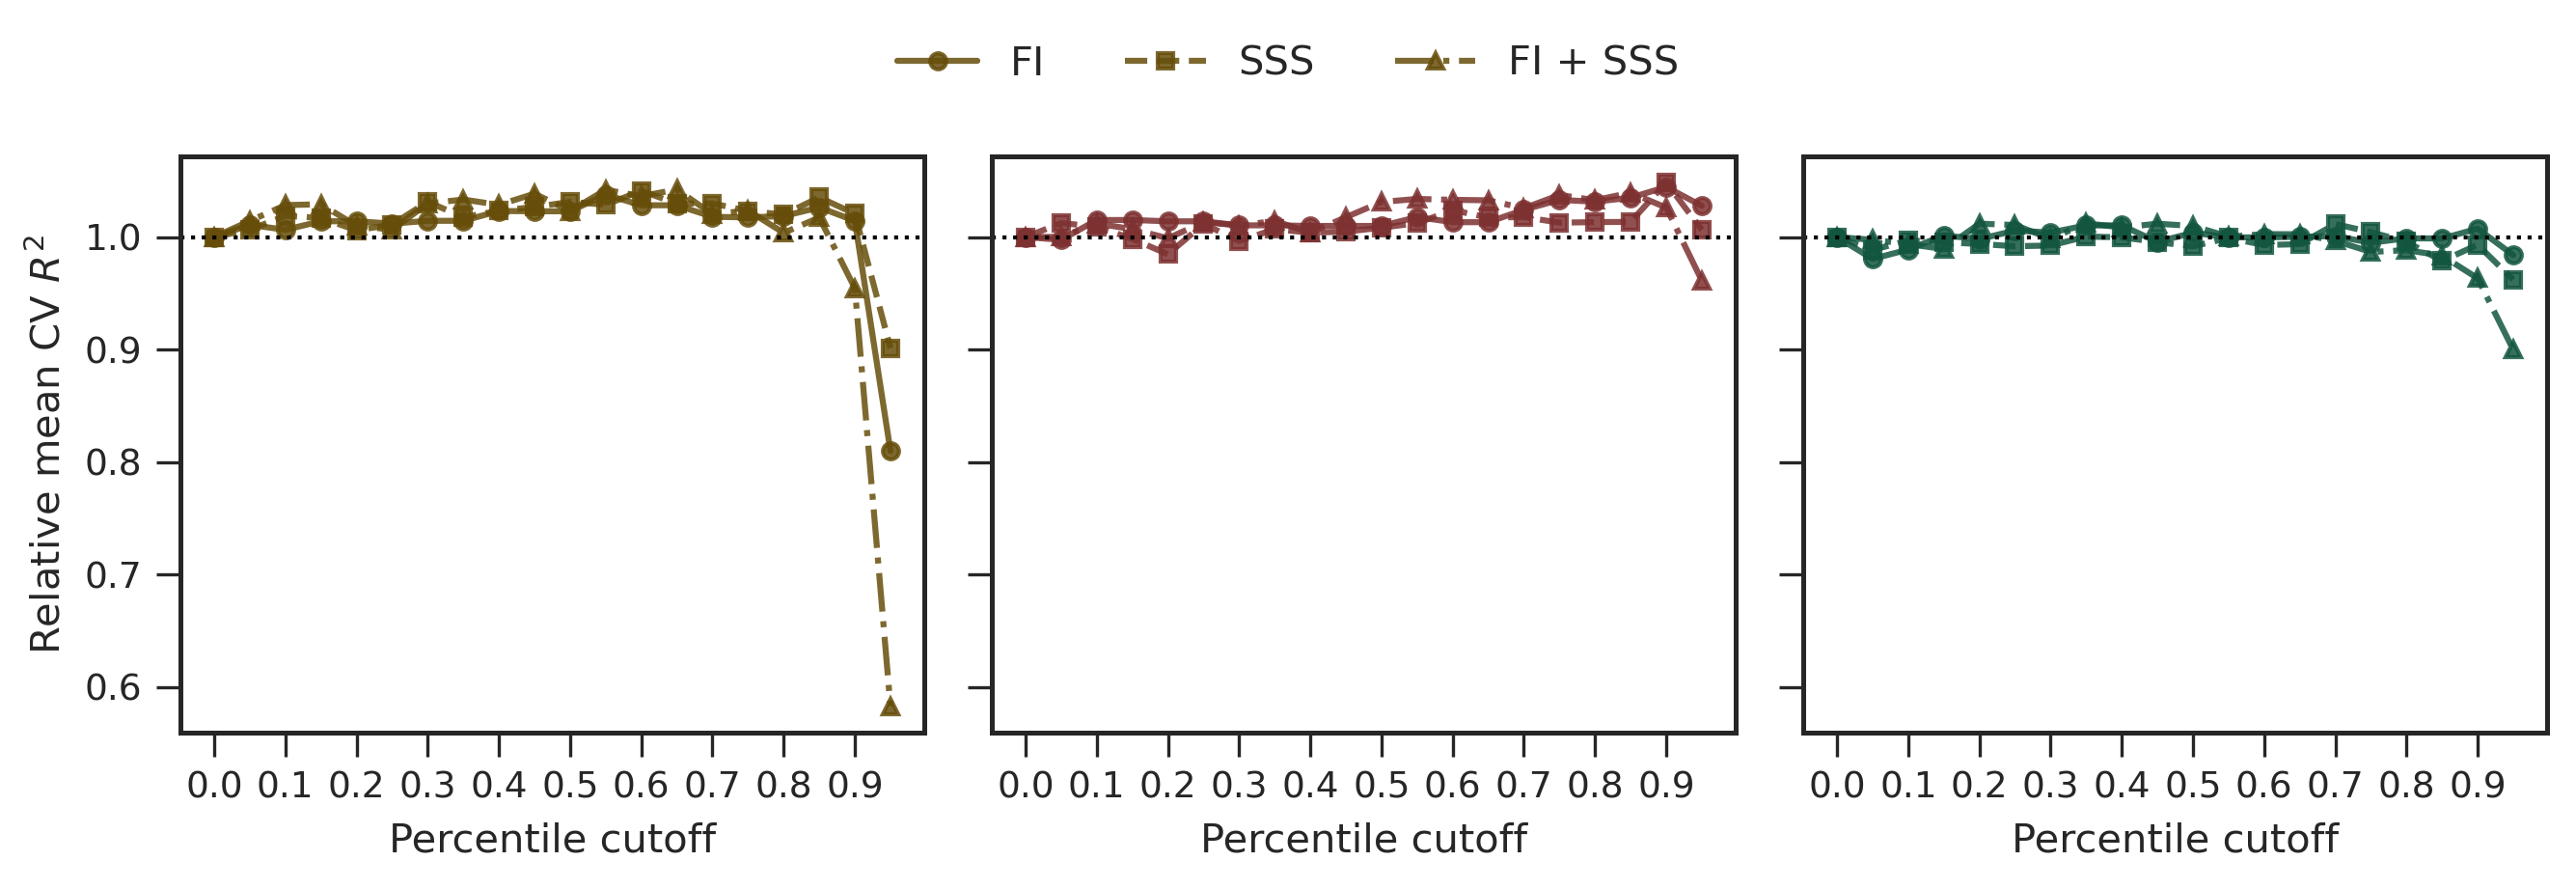

In [32]:
# ============================================
# FI-only vs SSS-only vs joint screening
# Relative CV performance across cutoffs
# ============================================

baseline_r2 = cutoff_grid_cv_df.query("FI_cutoff == 0 and SSS_cutoff == 0").set_index("Species")["CV_R2"]

paths = {
    "FI":      lambda d: np.isclose(d["SSS_cutoff"], 0),
    "SSS":     lambda d: np.isclose(d["FI_cutoff"], 0),
    "FI + SSS": lambda d: np.isclose(d["FI_cutoff"], d["SSS_cutoff"]),
}

rows = []
for species in ["AT", "NB", "OS"]:
    d = cutoff_grid_cv_df.query("Species == @species")
    for strategy, mask in paths.items():
        p = d.loc[mask(d)].copy()
        p["Strategy"] = strategy
        p["Cutoff"] = np.where(strategy == "FI", p["FI_cutoff"],
                      np.where(strategy == "SSS", p["SSS_cutoff"], p["FI_cutoff"]))
        p["Relative_CV_R2"] = p["CV_R2"] / baseline_r2[species]
        rows.append(p)

strategy_df = pd.concat(rows, ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(9, 3), dpi=_PLOT_CFG["dpi"], sharex=True, sharey=True)
style = {"FI": ("o", "-"), "SSS": ("s", "--"), "FI + SSS": ("^", "-.")}

for ax, species_key in zip(axes, SPECIES):
    species, color = SPECIES_INFO[species_key]["label"], SPECIES_INFO[species_key]["color"]

    for strategy, (marker, ls) in style.items():
        p = strategy_df.query("Species == @species and Strategy == @strategy").sort_values("Cutoff")
        ax.plot(p["Cutoff"], p["Relative_CV_R2"], marker=marker, ls=ls,
                lw=1.5, ms=4, color=color, alpha=0.85, label=strategy)

    ax.axhline(1, color="black", ls=":", lw=1)
    ax.set_xticks(np.arange(0, 1.0, 0.1))
    format_axis(ax, xlabel="Percentile cutoff",
                ylabel="Relative mean CV $R^2$" if ax is axes[0] else None)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.03),
           ncol=3, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()

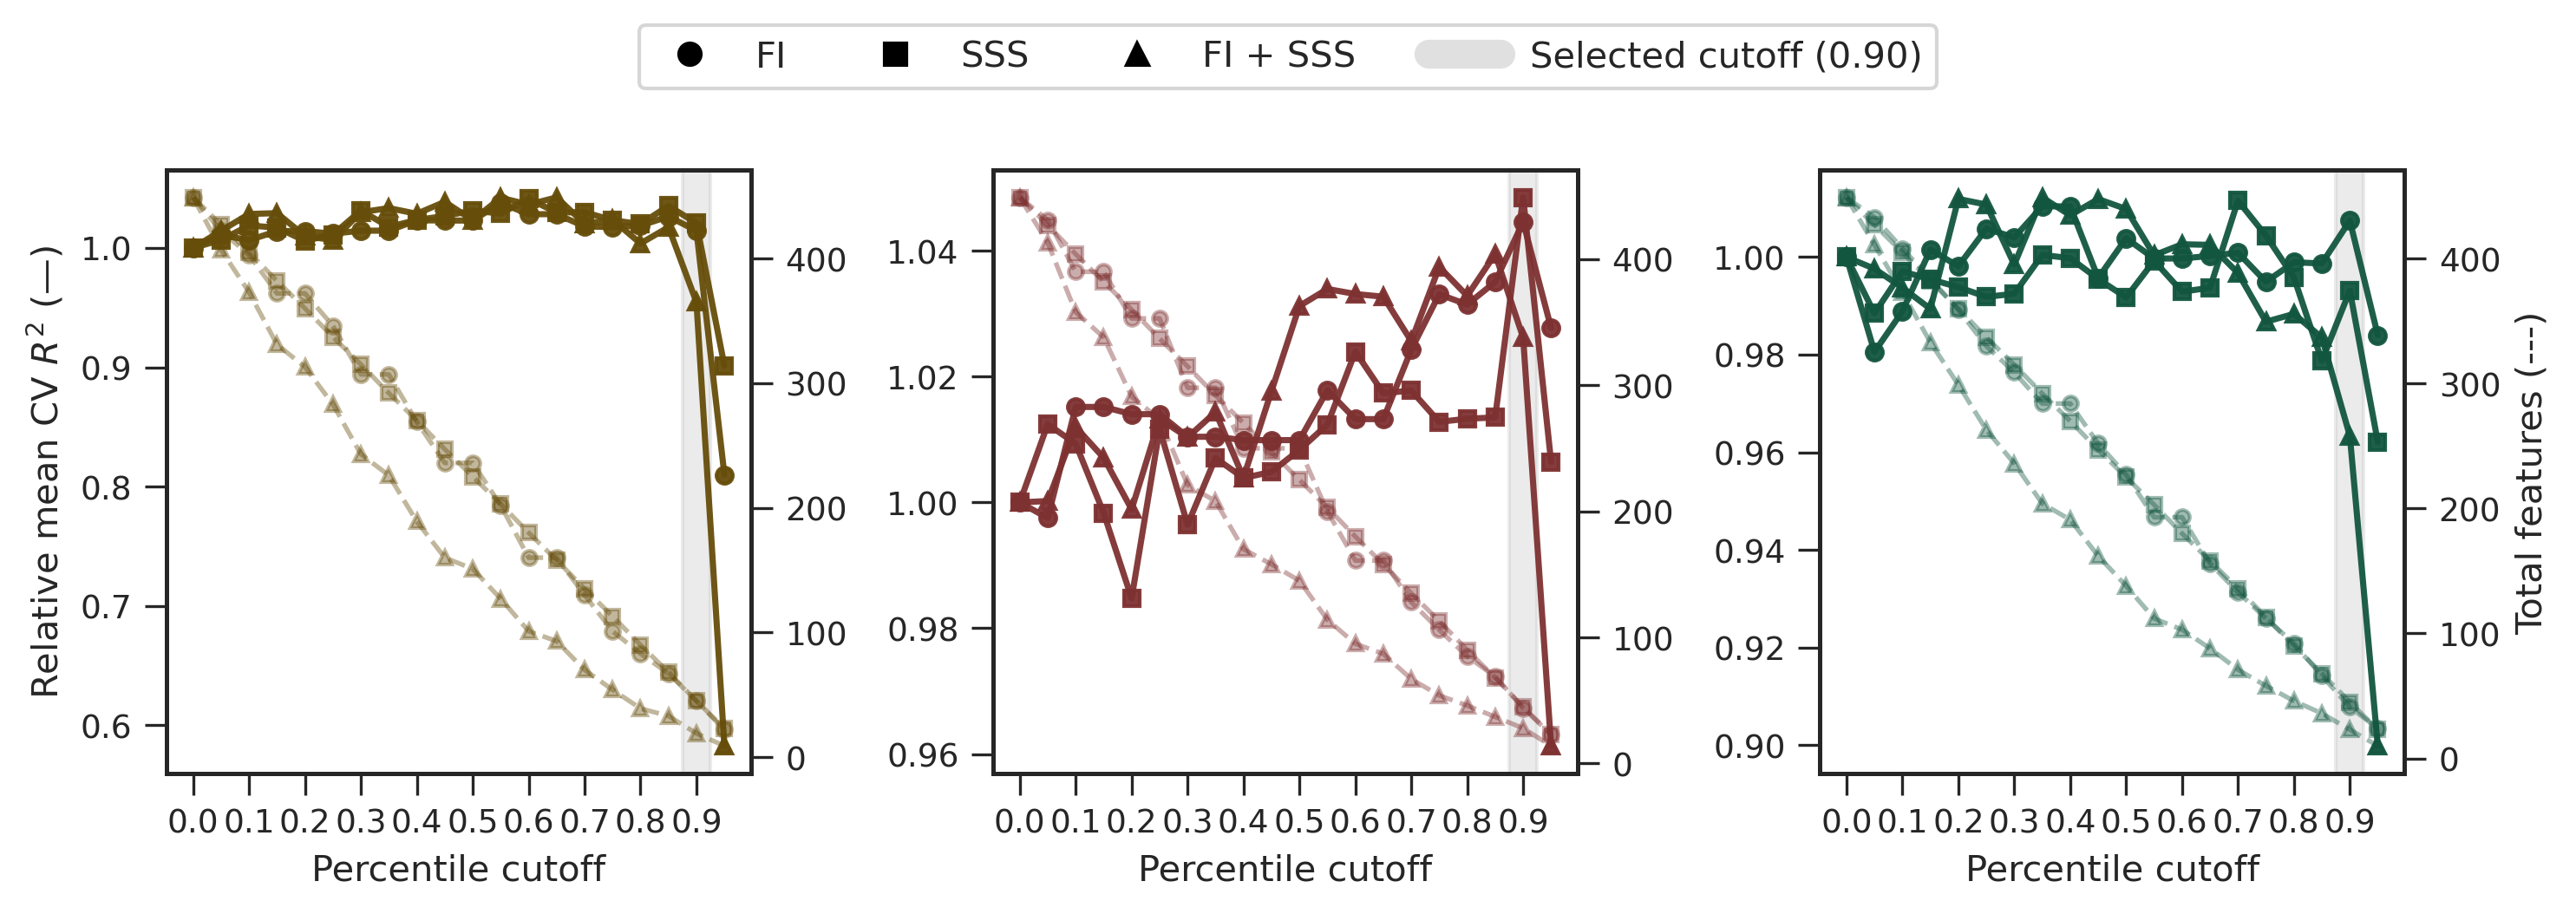

In [36]:
# ============================================
# FI vs SSS vs joint cutoff trade-off
# Relative CV R2 + total features
# ============================================

from matplotlib.lines import Line2D

baseline = cutoff_grid_cv_df.query(
    "FI_cutoff == 0 and SSS_cutoff == 0"
).set_index("Species")["CV_R2"]

paths = {
    "FI": lambda d: np.isclose(d["SSS_cutoff"], 0),
    "SSS": lambda d: np.isclose(d["FI_cutoff"], 0),
    "FI + SSS": lambda d: np.isclose(d["FI_cutoff"], d["SSS_cutoff"]),
}
markers = {"FI": "o", "SSS": "s", "FI + SSS": "^"}

rows = []
for species in ["AT", "NB", "OS"]:
    d = cutoff_grid_cv_df.query("Species == @species")
    for strategy, mask in paths.items():
        p = d.loc[mask(d)].copy()
        p["Strategy"] = strategy
        p["Cutoff"] = np.where(strategy == "FI", p["FI_cutoff"],
                      np.where(strategy == "SSS", p["SSS_cutoff"], p["FI_cutoff"]))
        p["Relative_CV_R2"] = p["CV_R2"] / baseline[species]
        rows.append(p)

strategy_df = pd.concat(rows, ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.4), dpi=_PLOT_CFG["dpi"], sharex=True)

for ax, species_key in zip(axes, SPECIES):
    species, color = SPECIES_INFO[species_key]["label"], SPECIES_INFO[species_key]["color"]
    ax2 = ax.twinx()

    for strategy, marker in markers.items():
        p = strategy_df.query("Species == @species and Strategy == @strategy").sort_values("Cutoff")

        ax.plot(
            p["Cutoff"], p["Relative_CV_R2"],
            color=color, marker=marker, ls="-", lw=1.7, ms=4.5, alpha=0.95,
        )
        ax2.plot(
            p["Cutoff"], p["N_features"],
            color=color, marker=marker, ls="--", lw=1.3, ms=4, alpha=0.40,
        )

    ax.axvspan(0.875, 0.925, color="0.75", alpha=0.30, zorder=0)
    ax.set_xticks(np.arange(0, 1.0, 0.1))

    format_axis(
        ax,
        xlabel="Percentile cutoff",
        ylabel="Relative mean CV $R^2$ (—)" if ax is axes[0] else None,
    )
    format_axis(
        ax2,
        ylabel="Total features (---)" if ax is axes[-1] else None,
    )

legend_handles = [
    Line2D([0], [0], color="black", marker=m, ls="None", ms=6, label=s)
    for s, m in markers.items()
] + [
    Line2D([0], [0], color="0.6", lw=8, alpha=0.30, label="Selected cutoff (0.90)")
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=4,
    frameon=True,
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

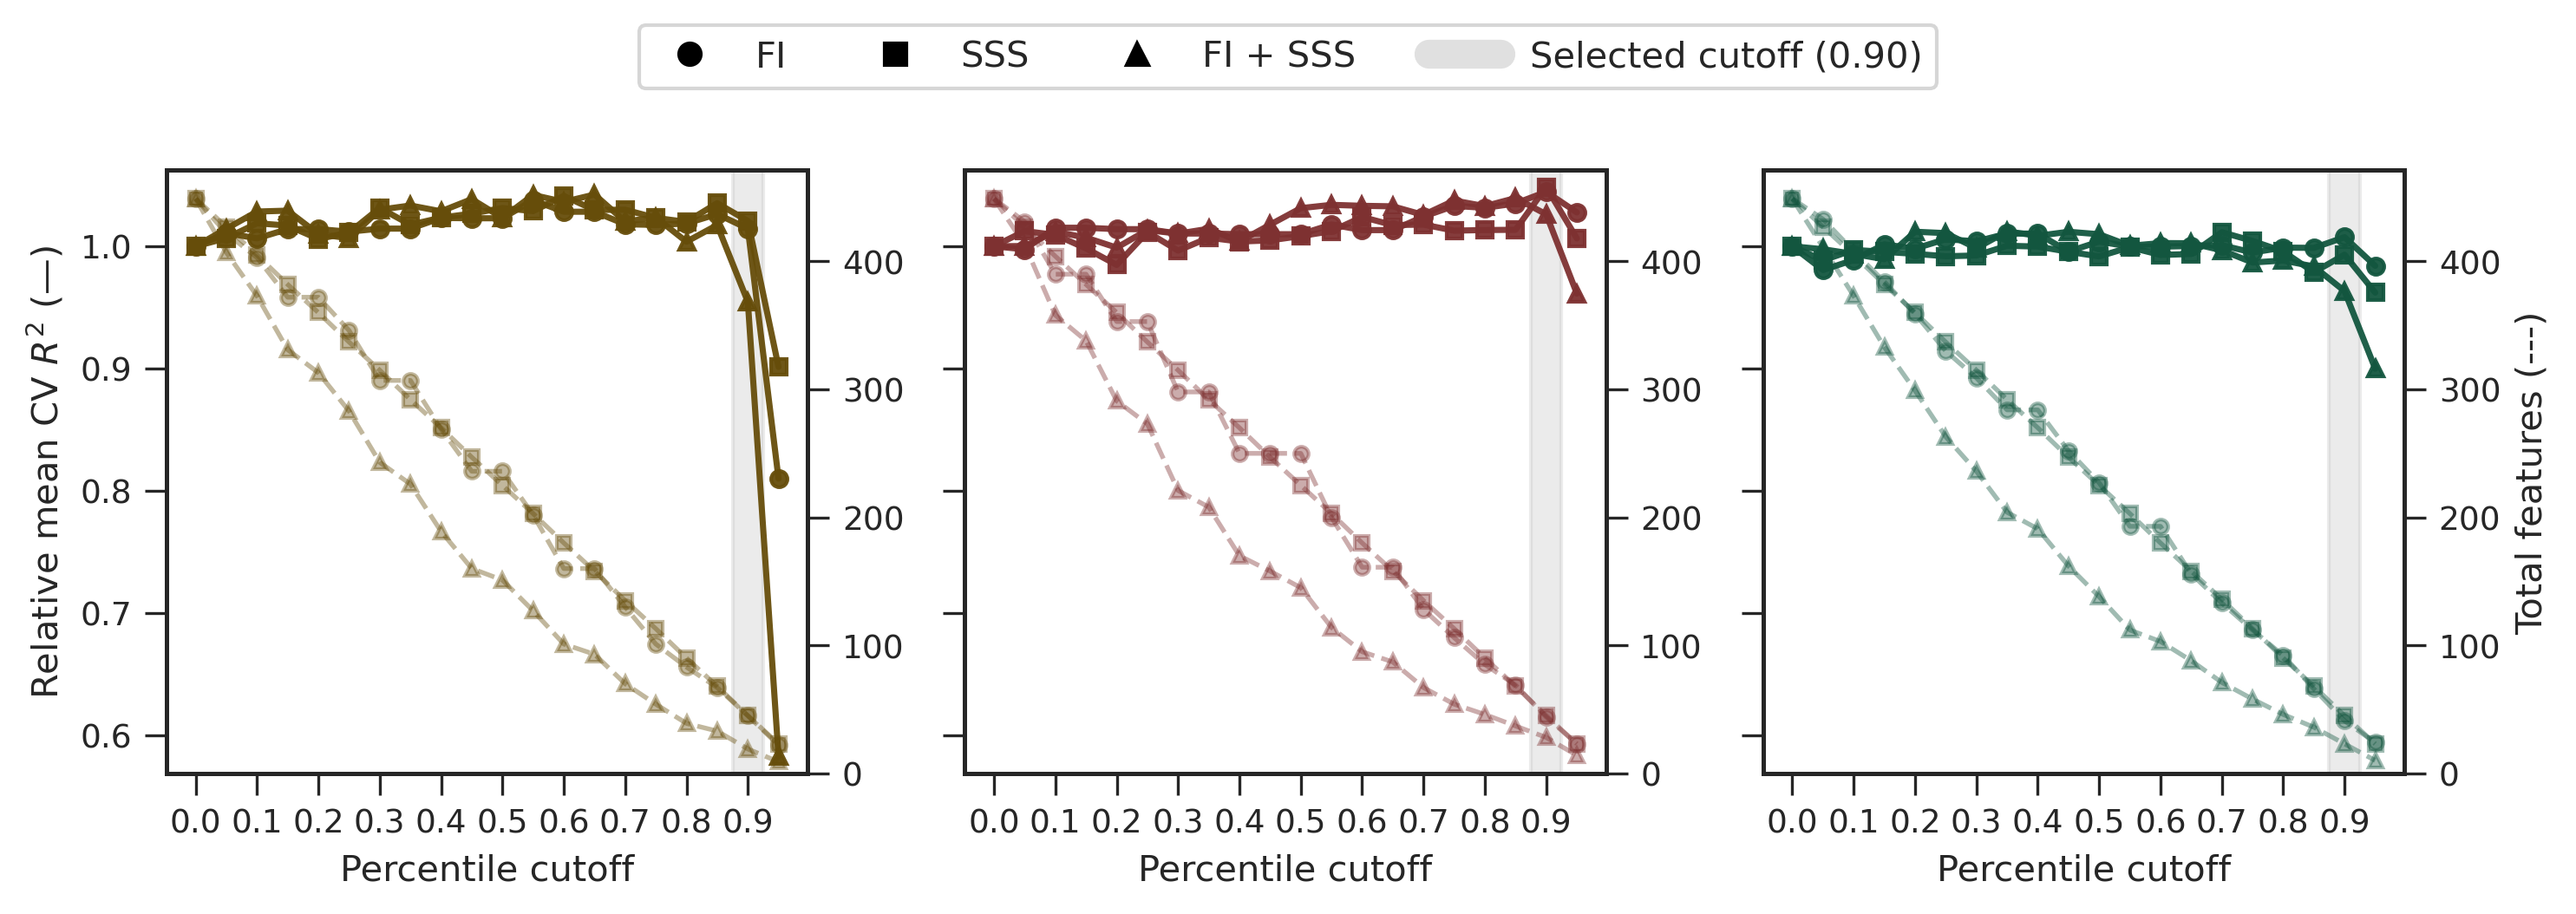

In [42]:
# ============================================
# FI vs SSS vs joint cutoff trade-off
# Aligned axes across species
# ============================================

from matplotlib.lines import Line2D

baseline = cutoff_grid_cv_df.query("FI_cutoff == 0 and SSS_cutoff == 0").set_index("Species")["CV_R2"]
paths = {"FI": lambda d: np.isclose(d["SSS_cutoff"], 0),
         "SSS": lambda d: np.isclose(d["FI_cutoff"], 0),
         "FI + SSS": lambda d: np.isclose(d["FI_cutoff"], d["SSS_cutoff"])}
markers = {"FI": "o", "SSS": "s", "FI + SSS": "^"}

rows = []
for species in ["AT", "NB", "OS"]:
    d = cutoff_grid_cv_df.query("Species == @species")
    for strategy, mask in paths.items():
        p = d.loc[mask(d)].copy()
        p["Strategy"] = strategy
        p["Cutoff"] = np.where(strategy == "FI", p["FI_cutoff"],
                      np.where(strategy == "SSS", p["SSS_cutoff"], p["FI_cutoff"]))
        p["Relative_CV_R2"] = p["CV_R2"] / baseline[species]
        rows.append(p)

strategy_df = pd.concat(rows, ignore_index=True)

r2_min, r2_max = strategy_df["Relative_CV_R2"].min(), strategy_df["Relative_CV_R2"].max()
r2_pad = 0.03 * (r2_max - r2_min)
n_max = strategy_df["N_features"].max()

fig, axes = plt.subplots(1, 3, figsize=(10, 3.4), dpi=_PLOT_CFG["dpi"], sharex=True, sharey=True)

for ax, species_key in zip(axes, SPECIES):
    species, color = SPECIES_INFO[species_key]["label"], SPECIES_INFO[species_key]["color"]
    ax2 = ax.twinx()

    for strategy, marker in markers.items():
        p = strategy_df.query("Species == @species and Strategy == @strategy").sort_values("Cutoff")

        ax.plot(p["Cutoff"], p["Relative_CV_R2"], color=color, marker=marker,
                ls="-", lw=1.7, ms=4.5, alpha=0.95)

        ax2.plot(p["Cutoff"], p["N_features"], color=color, marker=marker,
                 ls="--", lw=1.3, ms=4, alpha=0.40)

    ax.axvspan(0.875, 0.925, color="0.75", alpha=0.30, zorder=0)
    ax.set_xticks(np.arange(0, 1.0, 0.1))
    ax.set_ylim(r2_min - r2_pad, r2_max + r2_pad)
    ax2.set_ylim(0, n_max * 1.05)

    format_axis(
        ax,
        xlabel="Percentile cutoff",
        ylabel="Relative mean CV $R^2$ (—)" if ax is axes[0] else None,
    )
    format_axis(
        ax2,
        ylabel="Total features (---)" if ax is axes[-1] else None,
    )

legend_handles = [
    Line2D([0], [0], color="black", marker=m, ls="None", ms=6, label=s)
    for s, m in markers.items()
] + [
    Line2D([0], [0], color="0.6", lw=8, alpha=0.30, label="Selected cutoff (0.90)")
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=4,
    frameon=True,
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

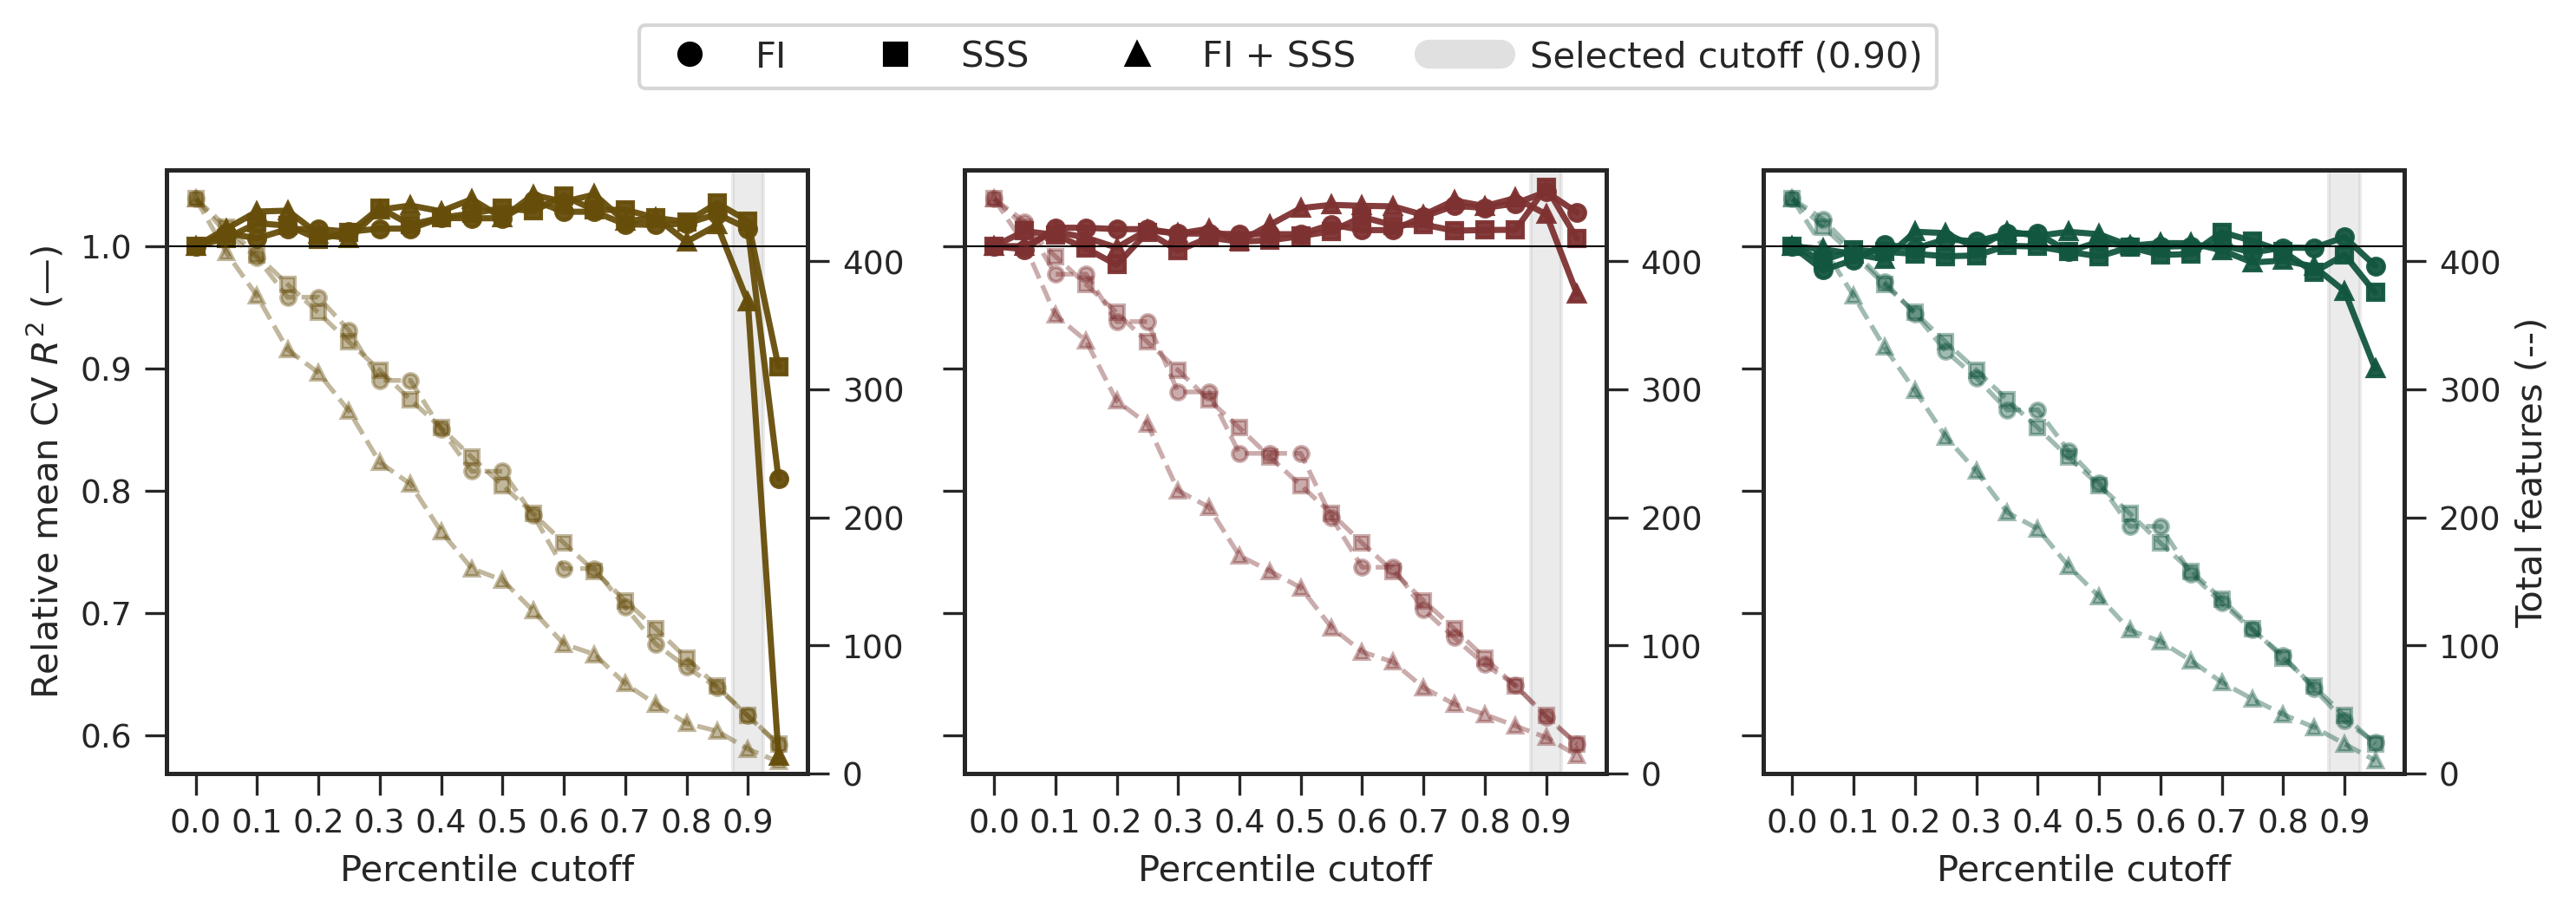

In [51]:
# ============================================
# FI vs SSS vs joint cutoff trade-off
# Screening baseline = FI 0.00 / SSS 0.00
# ============================================

from matplotlib.lines import Line2D

baseline = cutoff_grid_cv_df.query("FI_cutoff == 0 and SSS_cutoff == 0").set_index("Species")["CV_R2"]

paths = {
    "FI": lambda d: np.isclose(d["SSS_cutoff"], 0),
    "SSS": lambda d: np.isclose(d["FI_cutoff"], 0),
    "FI + SSS": lambda d: np.isclose(d["FI_cutoff"], d["SSS_cutoff"]),
}
markers = {"FI": "o", "SSS": "s", "FI + SSS": "^"}

rows = []
for species in ["AT", "NB", "OS"]:
    d = cutoff_grid_cv_df.query("Species == @species")
    for strategy, mask in paths.items():
        p = d.loc[mask(d)].copy()
        p["Strategy"] = strategy
        p["Cutoff"] = np.where(strategy == "FI", p["FI_cutoff"],
                      np.where(strategy == "SSS", p["SSS_cutoff"], p["FI_cutoff"]))
        p["Relative_CV_R2"] = p["CV_R2"] / baseline[species]
        rows.append(p)

strategy_df = pd.concat(rows, ignore_index=True)

r2_min, r2_max = strategy_df["Relative_CV_R2"].min(), strategy_df["Relative_CV_R2"].max()
r2_pad = 0.03 * (r2_max - r2_min)
n_max = strategy_df["N_features"].max()

fig, axes = plt.subplots(1, 3, figsize=(10, 3.4), dpi=_PLOT_CFG["dpi"], sharex=True, sharey=True)

for ax, species_key in zip(axes, SPECIES):
    species, color = SPECIES_INFO[species_key]["label"], SPECIES_INFO[species_key]["color"]
    ax2 = ax.twinx()

    for strategy, marker in markers.items():
        p = strategy_df.query("Species == @species and Strategy == @strategy").sort_values("Cutoff")

        ax.plot(p["Cutoff"], p["Relative_CV_R2"], color=color, marker=marker,
                ls="-", lw=1.7, ms=4.5, alpha=0.95)

        ax2.plot(p["Cutoff"], p["N_features"], color=color, marker=marker,
                 ls="--", lw=1.3, ms=4, alpha=0.40)

    ax.axhline(1.0, color="black", ls="-", lw=0.5)
    ax.axvspan(0.875, 0.925, color="0.75", alpha=0.30, zorder=0)

    ax.set_xticks(np.arange(0, 1.0, 0.1))
    ax.set_ylim(r2_min - r2_pad, r2_max + r2_pad)
    ax2.set_ylim(0, n_max * 1.05)

    format_axis(
        ax,
        xlabel="Percentile cutoff",
        ylabel="Relative mean CV $R^2$ (—)" if ax is axes[0] else None,
    )

    format_axis(
        ax2,
        ylabel="Total features (--)" if ax is axes[-1] else None,
    )

legend_handles = [
    Line2D([0], [0], color="black", marker=m, ls="None", ms=6, label=s)
    for s, m in markers.items()
] + [
    Line2D([0], [0], color="0.6", lw=8, alpha=0.30, label="Selected cutoff (0.90)")
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=4,
    frameon=True,
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

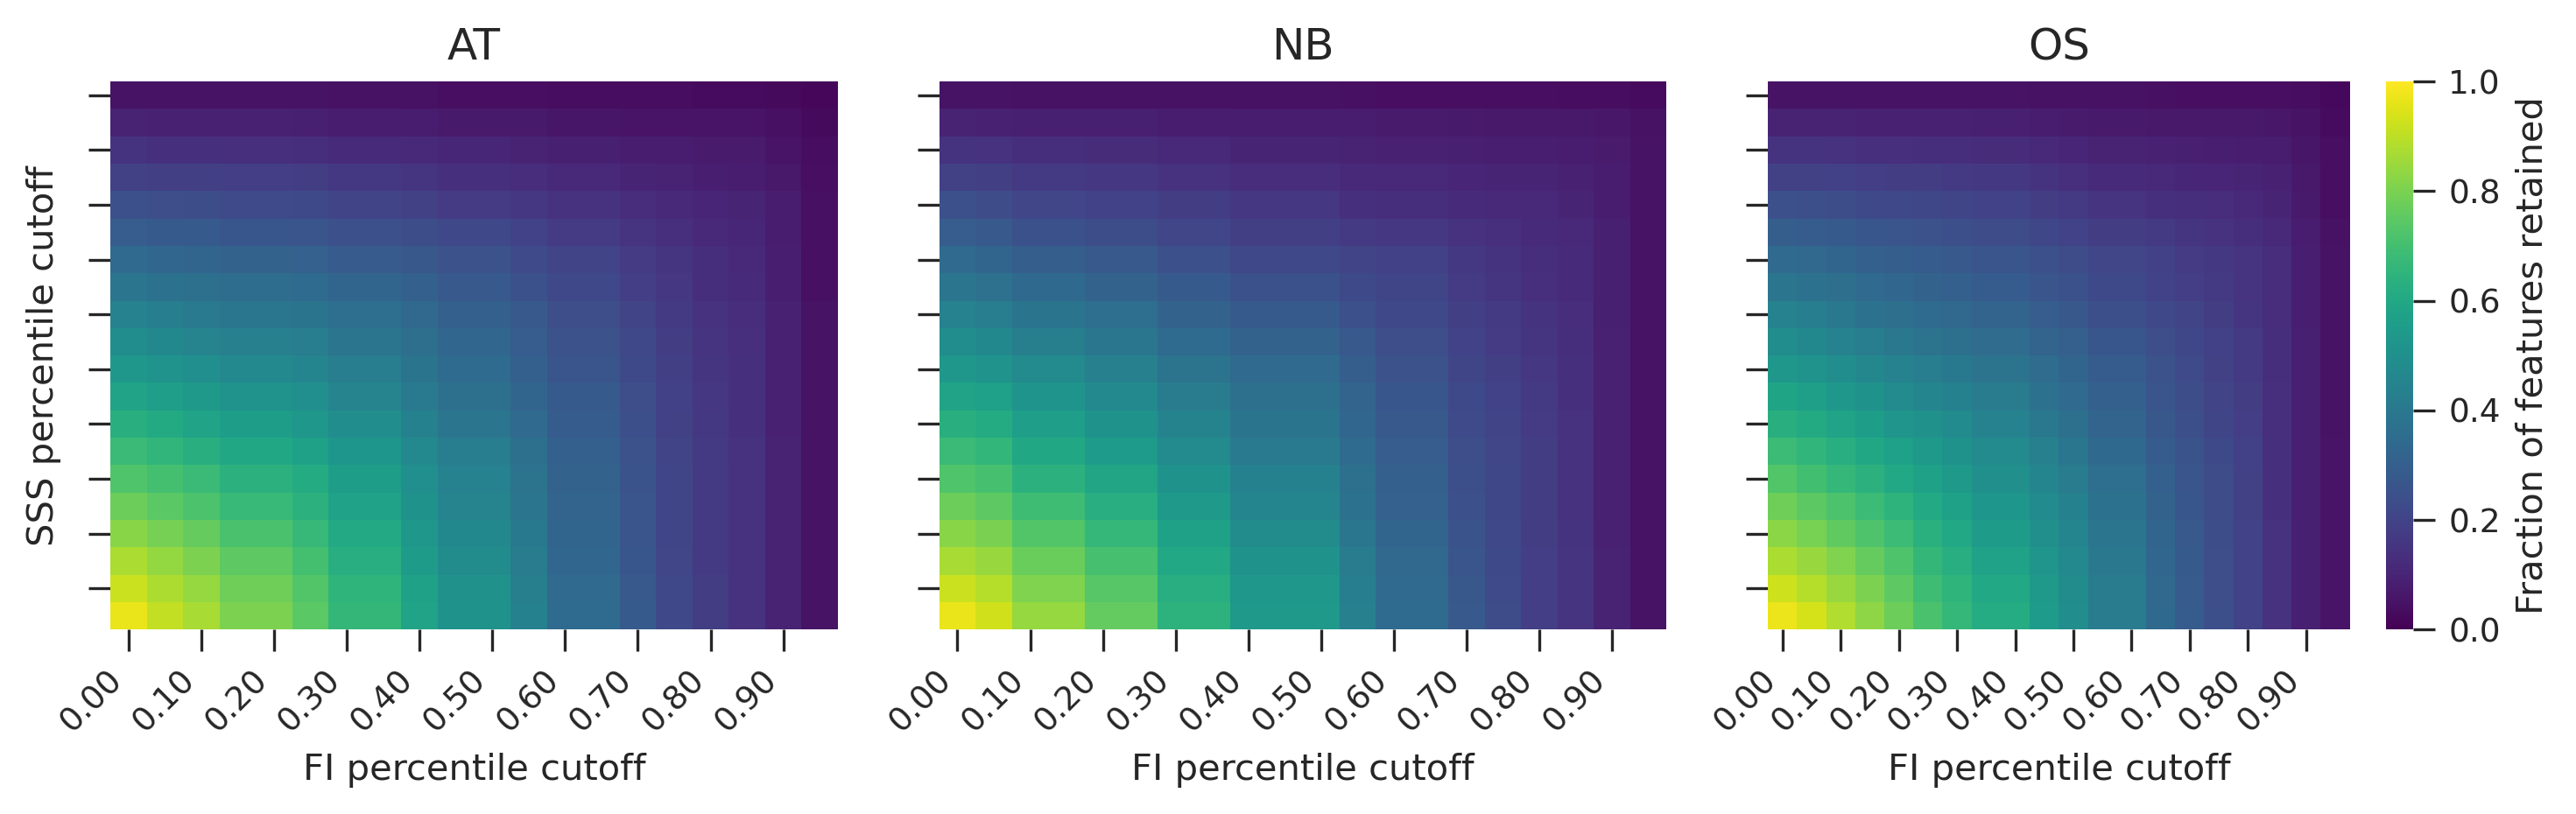

In [20]:
# ============================================
# FI × SSS cutoff landscape
# Fraction of features retained
# ============================================

retention_grid_df = cutoff_grid_cv_df.copy()
baseline_n = {k: len(lgbm_bundles[k]["feature_names"]) for k in SPECIES}
retention_grid_df["Baseline_features"] = retention_grid_df["Species"].map(
    {SPECIES_INFO[k]["label"]: baseline_n[k] for k in SPECIES}
)
retention_grid_df["Fraction_retained"] = retention_grid_df["N_features"] / retention_grid_df["Baseline_features"]

fig, axes = plt.subplots(1, 3, figsize=(10, 3.2), dpi=_PLOT_CFG["dpi"], sharex=True, sharey=True)

for ax, species_key in zip(axes, SPECIES):
    species = SPECIES_INFO[species_key]["label"]
    temp = retention_grid_df.loc[retention_grid_df["Species"] == species]
    mat = temp.pivot(index="SSS_cutoff", columns="FI_cutoff", values="Fraction_retained").sort_index(ascending=False)

    sns.heatmap(
        mat, cmap="viridis", vmin=0, vmax=1, ax=ax, cbar=ax is axes[-1],
        cbar_kws={"label": "Fraction of features retained"} if ax is axes[-1] else None,
    )

    ax.set_title(species)
    ax.set_xlabel("FI percentile cutoff")
    ax.set_ylabel("SSS percentile cutoff" if ax is axes[0] else "")
    ax.set_xticklabels([f"{float(x.get_text()):.2f}" for x in ax.get_xticklabels()], rotation=45, ha="right")
    ax.set_yticklabels([f"{float(y.get_text()):.2f}" for y in ax.get_yticklabels()], rotation=0)

plt.tight_layout()
plt.show()

In [43]:
# ============================================
# Joint FI + SSS cutoff decision table
# ============================================

base = (cutoff_grid_cv_df.query("FI_cutoff == 0 and SSS_cutoff == 0")
        .set_index("Species")["CV_R2"].to_dict())

joint = strategy_df.query("Strategy == 'FI + SSS'").copy()
joint["Relative_CV_R2"] = joint["CV_R2"] / joint["Species"].map(base)

decision_df = (joint.pivot(index="Cutoff", columns="Species",
                           values=["Relative_CV_R2", "N_features"]).sort_index())

decision_df.columns = [f"{s}_{m}" for m, s in decision_df.columns]
decision_df["Worst_Relative_CV_R2"] = decision_df[
    ["AT_Relative_CV_R2", "NB_Relative_CV_R2", "OS_Relative_CV_R2"]
].min(axis=1)

decision_df["Total_features"] = decision_df[
    ["AT_N_features", "NB_N_features", "OS_N_features"]
].sum(axis=1)

decision_df = decision_df.reset_index()

display(decision_df.loc[decision_df["Cutoff"] >= 0.70].style.format({
    "Cutoff": "{:.2f}",
    "AT_Relative_CV_R2": "{:.3f}", "NB_Relative_CV_R2": "{:.3f}",
    "OS_Relative_CV_R2": "{:.3f}", "Worst_Relative_CV_R2": "{:.3f}",
    "AT_N_features": "{:.0f}", "NB_N_features": "{:.0f}",
    "OS_N_features": "{:.0f}", "Total_features": "{:.0f}",
}))

,Cutoff,AT_Relative_CV_R2,NB_Relative_CV_R2,OS_Relative_CV_R2,AT_N_features,NB_N_features,OS_N_features,Worst_Relative_CV_R2,Total_features
14,0.70,1.020,1.026,0.997,70,67,71,0.997,208
15,0.75,1.024,1.037,0.987,54,54,58,0.987,166
16,0.80,1.004,1.033,0.988,39,46,46,0.988,131
17,0.85,1.017,1.039,0.983,33,37,36,0.983,106
18,0.90,0.955,1.026,0.963,19,28,23,0.955,70
19,0.95,0.583,0.961,0.900,9,14,10,0.583,33


In [44]:
# ============================================
# Audit CV baselines
# ============================================

old_base = (
    retention_cv_df.groupby("Species", as_index=False)
    .agg(Old_CV_R2=("Full_CV_R2", "first"))
)

grid_base = (
    cutoff_grid_cv_df.query("FI_cutoff == 0 and SSS_cutoff == 0")
    [["Species", "CV_R2", "CV_R2_SD", "N_features"]]
    .rename(columns={"CV_R2": "Grid_CV_R2", "CV_R2_SD": "Grid_CV_R2_SD"})
)

audit_df = old_base.merge(grid_base, on="Species")
audit_df["Difference"] = audit_df["Grid_CV_R2"] - audit_df["Old_CV_R2"]
audit_df["Difference_pct"] = 100 * audit_df["Difference"] / audit_df["Old_CV_R2"]

display(audit_df.style.format({
    "Old_CV_R2": "{:.6f}", "Grid_CV_R2": "{:.6f}",
    "Grid_CV_R2_SD": "{:.6f}", "Difference": "{:+.6f}",
    "Difference_pct": "{:+.2f}%", "N_features": "{:.0f}",
}))

,Species,Old_CV_R2,Grid_CV_R2,Grid_CV_R2_SD,N_features,Difference,Difference_pct
0,AT,0.250487,0.246176,0.036747,449,-0.004311,-1.72%
1,NB,0.309222,0.308877,0.028093,449,-0.000345,-0.11%
2,OS,0.361391,0.360750,0.052351,449,-0.000641,-0.18%


In [45]:
# ============================================
# Audit CV result structures
# ============================================

print("retention_cv_df")
print(retention_cv_df.columns.tolist())
print(retention_cv_df.shape)

print("\ncutoff_grid_cv_df")
print(cutoff_grid_cv_df.columns.tolist())
print(cutoff_grid_cv_df.shape)

print("\nOld full-model baselines")
display(
    retention_cv_df.groupby("Species")[
        ["Full_CV_R2"]
    ].agg(["count", "nunique", "min", "max"])
)

print("\nGrid baseline")
display(
    cutoff_grid_cv_df.query(
        "FI_cutoff == 0 and SSS_cutoff == 0"
    )[["Species", "N_features", "CV_R2", "CV_R2_SD"]]
)

retention_cv_df
['Species', 'Cutoff', 'N_features', 'Full_CV_R2', 'Full_CV_R2_SD', 'Reduced_CV_R2', 'CV_R2_SD']
(60, 7)

cutoff_grid_cv_df
['Species', 'FI_cutoff', 'SSS_cutoff', 'N_features', 'CV_R2', 'CV_R2_SD', 'Relative_CV_R2']
(1200, 7)

Old full-model baselines


Full_CV_R2                            
             count nunique       min       max
Species                                       
AT              20       1  0.250487  0.250487
NB              20       1  0.309222  0.309222
OS              20       1  0.361391  0.361391


Grid baseline


,Species,N_features,CV_R2,CV_R2_SD
0,AT,449,0.246176,0.036747
400,NB,449,0.308877,0.028093
800,OS,449,0.360750,0.052351


In [46]:
retention_cv_df

,Species,Cutoff,N_features,Full_CV_R2,Full_CV_R2_SD,Reduced_CV_R2,CV_R2_SD
0,AT,0.00,449,0.250487,0.037655,0.246176,0.036747
1,AT,0.05,407,0.250487,0.037655,0.249711,0.037194
2,AT,0.10,373,0.250487,0.037655,0.253173,0.038253
3,AT,0.15,331,0.250487,0.037655,0.253356,0.033886
4,AT,0.20,313,0.250487,0.037655,0.248637,0.035945
5,AT,0.25,283,0.250487,0.037655,0.247786,0.033800
6,AT,0.30,243,0.250487,0.037655,0.253541,0.032040
7,AT,0.35,226,0.250487,0.037655,0.254394,0.032797
8,AT,0.40,189,0.250487,0.037655,0.253222,0.037942
9,AT,0.45,160,0.250487,0.037655,0.255678,0.037721


In [47]:
cutoff_grid_cv_df

,Species,FI_cutoff,SSS_cutoff,N_features,CV_R2,CV_R2_SD,Relative_CV_R2
0,AT,0.00,0.00,449,0.246176,0.036747,1.000000
1,AT,0.00,0.05,427,0.247811,0.037782,1.006643
2,AT,0.00,0.10,405,0.250809,0.035531,1.018822
3,AT,0.00,0.15,382,0.250355,0.036821,1.016977
4,AT,0.00,0.20,360,0.247650,0.037175,1.005989
...,...,...,...,...,...,...,...
1195,OS,0.95,0.75,18,0.333199,0.053918,0.923628
1196,OS,0.95,0.80,18,0.333199,0.053918,0.923628
1197,OS,0.95,0.85,17,0.336356,0.051315,0.932380
1198,OS,0.95,0.90,14,0.333525,0.047781,0.924533
